### 1. Install Dependencies

In [1]:
!python -m pip install -q timm pandas matplotlib kaggle scikit-learn wandb grad-cam seaborn albumentations

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
aiter 0.1.5.post2.dev17+g3d48b72be.d20250912 requires pybind11<3,>=2.13, but you have pybind11 3.0.1 which is incompatible.

[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


### 2. Imports

In [2]:
import os
import gc
import re
import time
import math
import random
import warnings
from dataclasses import dataclass
from pathlib import Path
from tqdm.auto import tqdm
import json
import shutil
import zipfile
import subprocess
from datetime import datetime
import seaborn as sns
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import wandb
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
os.environ["PYTHONHASHSEED"] = "42"
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode, RandomResizedCrop
from torch.optim.lr_scheduler import _LRScheduler, CosineAnnealingLR
import timm
import cv2
import albumentations as A
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

warnings.filterwarnings("ignore")

[aiter] start build [module_aiter_enum] under /workspace/aiter/aiter/jit/build/module_aiter_enum
Successfully preprocessed all matching files.
[aiter] finish build [module_aiter_enum], cost 20.52528416s
/opt/venv/lib/python3.10/site-packages/apex/transformer/functional/fused_rope.py:49: UserWarning: Aiter backend is selected for fused RoPE. This has lower precision. To disable aiter, export USE_ROCM_AITER_ROPE_BACKEND=0
  warnings.warn("Aiter backend is selected for fused RoPE. This has lower precision. To disable aiter, export USE_ROCM_AITER_ROPE_BACKEND=0", UserWarning)


### 3. Experiment Config & Paths

In [3]:
EXPERIMENT_CODE = "E01"
SEED = 42

# Reproducibility
DETERMINISTIC = True
DETERMINISTIC_WARN_ONLY = True
DISABLE_TF32 = True

# IDENTIFIKASI ENVIRONMENT
IS_KAGGLE = Path("/kaggle/input").exists() and Path("/kaggle/working").exists()
IS_VIDEOMAE_NOTEBOOK = "VideoMAEForVideoClassification" in globals()

MODEL_KIND = (
    "spatiotemporal_videomae"
    if IS_VIDEOMAE_NOTEBOOK
    else "spatial_vit"
)

# DATASET
KAGGLE_DATASET_SLUG = "afenmarbun/wilddeepfake-46f"
KAGGLE_DATASET_DIRNAME = "wilddeepfake-46f"
INDEX_DIRNAME = "wdf46f_index"

FORCE_REDOWNLOAD_DATASET = False
FORCE_REEXTRACT_DATASET = False

# CHECKPOINT VIDEOMAE
KAGGLE_MODEL_VERSION_SLUG = (
    "afenmarbun/videomae-base-finetuned-ssv2/pytorch/default/1"
)
KAGGLE_MODEL_DIRNAME = "videomae-base-finetuned-ssv2"
FORCE_REDOWNLOAD_MODEL = False

if IS_KAGGLE:
    # Dataset
    DATASET_ROOT_CANDIDATES = [
        Path("/kaggle/input") / KAGGLE_DATASET_DIRNAME,
        Path("/kaggle/input/datasets/afenmarbun") / KAGGLE_DATASET_DIRNAME,
        Path("/kaggle/input") / KAGGLE_DATASET_SLUG.split("/")[-1],
    ]

    DATASET_ROOT = next(
        (p for p in DATASET_ROOT_CANDIDATES if p.exists()),
        DATASET_ROOT_CANDIDATES[0],
    )

    # Index/split
    INDEX_ROOT_CANDIDATES = [
        Path("/kaggle/input/notebooks/afenmarbun/build-index-and-splits") / INDEX_DIRNAME,
        Path("/kaggle/input/build-index-and-splits") / INDEX_DIRNAME,
        Path("/kaggle/input") / INDEX_DIRNAME,
    ]

    INDEX_ROOT = next(
        (p for p in INDEX_ROOT_CANDIDATES if p.exists()),
        INDEX_ROOT_CANDIDATES[0],
    )

    # Checkpoint VideoMAE
    MODEL_ROOT = Path("/kaggle/input/models/afenmarbun/videomae-base-finetuned-ssv2/pytorch/default/1")

    MODEL_CHECKPOINT_CANDIDATES = [
        MODEL_ROOT / KAGGLE_MODEL_DIRNAME,
        MODEL_ROOT,
        Path("/kaggle/input") / KAGGLE_MODEL_DIRNAME,
    ]

    MODEL_CHECKPOINT = next(
        (p for p in MODEL_CHECKPOINT_CANDIDATES if p.exists()),
        MODEL_CHECKPOINT_CANDIDATES[0],
    )

    WORKSPACE_ROOT = Path("/kaggle/working")
    RUNTIME_ROOT = WORKSPACE_ROOT / "wdf46f_runtime"
    KAGGLE_ZIP_DIR = RUNTIME_ROOT / "kaggle_zip"
    OUTPUT_ROOT = WORKSPACE_ROOT / "experiments" / MODEL_KIND

else:
    DEFAULT_WORKSPACE_ROOT = (
        "/workspace"
        if Path("/workspace").exists()
        else str(Path.cwd())
    )

    WORKSPACE_ROOT = Path(
        os.environ.get("WDF_WORKSPACE_ROOT", DEFAULT_WORKSPACE_ROOT)
    ).expanduser().resolve()

    RUNTIME_ROOT = WORKSPACE_ROOT / "wdf46f_runtime"

    KAGGLE_ZIP_DIR = RUNTIME_ROOT / "kaggle_zip"
    DATASET_ROOT = RUNTIME_ROOT / KAGGLE_DATASET_DIRNAME
    INDEX_ROOT = RUNTIME_ROOT / INDEX_DIRNAME

    MODEL_ROOT = RUNTIME_ROOT / "kaggle_models"
    MODEL_CHECKPOINT = MODEL_ROOT / KAGGLE_MODEL_DIRNAME

    OUTPUT_ROOT = WORKSPACE_ROOT / "experiments" / MODEL_KIND

# MODEL SPASIAL VIT
MODEL_NAME = "vit_base_patch16_224.mae"

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IS_ROCM = torch.version.hip is not None
USE_AMP = DEVICE.type == "cuda"
AMP_DTYPE = torch.bfloat16 if IS_ROCM else torch.float16
USE_GRAD_SCALER = USE_AMP and AMP_DTYPE == torch.float16

# LABEL
CLASS_TO_IDX = {"real": 0, "fake": 1}
IDX_TO_CLASS = {0: "real", 1: "fake"}

# HYPERPARAMETER
BATCH_SIZE_CLIPS = 32
EPOCHS = 25
LR = 5e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 8

# DROPOUT ABLATION
# Gunakan 0.0 untuk baseline tanpa dropout.
# Gunakan 0.1 untuk eksperimen dropout.
DROPOUT_RATE = 0.0
ATTENTION_DROPOUT_RATE = 0.0
DROP_PATH_RATE = 0.0

USE_EARLY_STOPPING = False
EARLY_STOPPING_PATIENCE = 4

SCHEDULER_NAME = "LinearDecayLR"
SCHEDULER_START_DECAY = EPOCHS // 4
SCHEDULER_BOOSTER = 2

IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".webp"}

# Geometry augmentation
AUG_GEOMETRY_ONEOF_PROB = 0.5

AUG_PROB_HFLIP = 0.5

AUG_CROP_LIMIT = 0.15
AUG_CROP_PROB = 0.5

AUG_SCALE_LIMIT = 0.15
AUG_SCALE_PROB = 0.5

# Color / degradation augmentation
AUG_COLORJITTER_PROB = 0.3
AUG_COLORJITTER_BRIGHTNESS = 0.2
AUG_COLORJITTER_CONTRAST = 0.2
AUG_COLORJITTER_SATURATION = 0.2
AUG_COLORJITTER_HUE = 0.2

AUG_BLUR_OR_NOISE_ONEOF_PROB = 0.5

AUG_GAUSSIAN_BLUR_PROB = 0.3
AUG_GAUSSIAN_BLUR_LIMIT = (3, 7)

AUG_GAUSSNOISE_PROB = 0.3
AUG_GAUSSNOISE_VAR_LIMIT = (10.0, 50.0)

# LOSS
USE_FOCAL_LOSS = False
FOCAL_GAMMA = 2.0
USE_FOCAL_ALPHA = True

# NORMALISASI
NORM_MEAN = (0.485, 0.456, 0.406)
NORM_STD = (0.229, 0.224, 0.225)

if IS_KAGGLE and not DATASET_ROOT.exists():
    print(
        "Peringatan: DATASET_ROOT tidak ditemukan. "
        "Pastikan dataset sudah ditambahkan melalui Add Data."
    )

### 4. Dataset Setup & Index Validation

In [4]:
# FALLBACK KONFIGURASI
IS_VIDEOMAE_NOTEBOOK = bool(
    globals().get(
        "IS_VIDEOMAE_NOTEBOOK",
        "VideoMAEForVideoClassification" in globals(),
    )
)

FORCE_REDOWNLOAD_DATASET = bool(globals().get("FORCE_REDOWNLOAD_DATASET", False))
FORCE_REEXTRACT_DATASET = bool(globals().get("FORCE_REEXTRACT_DATASET", False))
FORCE_REDOWNLOAD_MODEL = bool(globals().get("FORCE_REDOWNLOAD_MODEL", False))

RUNTIME_ROOT = Path(
    globals().get(
        "RUNTIME_ROOT",
        Path("/kaggle/working/wdf46f_runtime")
        if IS_KAGGLE
        else Path("/workspace/wdf46f_runtime")
        if Path("/workspace").exists()
        else Path.cwd() / "wdf46f_runtime",
    )
)

KAGGLE_ZIP_DIR = Path(
    globals().get("KAGGLE_ZIP_DIR", RUNTIME_ROOT / "kaggle_zip")
)

MODEL_ROOT = Path(
    globals().get("MODEL_ROOT", RUNTIME_ROOT / "kaggle_models")
)

KAGGLE_MODEL_DIRNAME = globals().get(
    "KAGGLE_MODEL_DIRNAME",
    "videomae-base-finetuned-ssv2",
)

KAGGLE_MODEL_VERSION_SLUG = globals().get(
    "KAGGLE_MODEL_VERSION_SLUG",
    None,
)

MODEL_CHECKPOINT = Path(
    globals().get("MODEL_CHECKPOINT", MODEL_ROOT / KAGGLE_MODEL_DIRNAME)
)

REQUIRED_INDEX_FILES = [
    "dataset_info.json",
    "experiment_configs.json",
    "sampling_preview.csv",
    "train_split.csv",
    "val_split.csv",
    "test_split.csv",
]

REQUIRED_SPLIT_COLUMNS = {
    "label",
    "label_name",
    "clip_dir_rel",
    "num_frames",
    "group_id",
}

SPLIT_FILES = {
    "train": "train_split.csv",
    "validation": "val_split.csv",
    "test": "test_split.csv",
}


# UTILITAS UMUM
def print_section(title: str):
    print("\n" + "=" * 72)
    print(title)
    print("=" * 72)


def run_command(cmd: list[str]):
    print("Menjalankan:", " ".join(cmd))
    subprocess.run(cmd, check=True)


def has_directory_content(path: Path, ignored_names: set[str] | None = None) -> bool:
    ignored_names = ignored_names or set()

    if not path.exists():
        return False

    return any(item.name not in ignored_names for item in path.iterdir())


def assert_safe_to_clear(path: Path):
    resolved = path.expanduser().resolve()

    forbidden_paths = {
        Path("/").resolve(),
        Path.home().resolve(),
        Path("/workspace").resolve() if Path("/workspace").exists() else None,
        Path("/kaggle").resolve() if Path("/kaggle").exists() else None,
        Path("/kaggle/working").resolve() if Path("/kaggle/working").exists() else None,
    }
    forbidden_paths = {p for p in forbidden_paths if p is not None}

    if resolved in forbidden_paths or len(resolved.parts) < 3:
        raise RuntimeError(
            f"Path terlalu berisiko untuk dibersihkan: {resolved}"
        )


def clear_directory(path: Path, keep_names: set[str] | None = None):
    keep_names = keep_names or set()
    assert_safe_to_clear(path)

    if not path.exists():
        return

    for item in path.iterdir():
        if item.name in keep_names:
            continue

        if item.is_dir():
            shutil.rmtree(item)
        else:
            item.unlink()


# KAGGLE CREDENTIAL
def setup_kaggle_credentials():
    """
    Menyiapkan credential Kaggle pada environment non-Kaggle.

    Prioritas:
    1. KAGGLE_JSON
    2. KAGGLE_USERNAME dan KAGGLE_KEY
    3. File kaggle.json pada lokasi umum
    """
    kaggle_dir = Path.home() / ".kaggle"
    kaggle_dir.mkdir(parents=True, exist_ok=True)

    kaggle_json_path = kaggle_dir / "kaggle.json"

    kaggle_json_env = os.environ.get("KAGGLE_JSON")
    kaggle_username = os.environ.get("KAGGLE_USERNAME")
    kaggle_key = os.environ.get("KAGGLE_KEY")

    if kaggle_json_env:
        creds = json.loads(kaggle_json_env)
        kaggle_json_path.write_text(json.dumps(creds), encoding="utf-8")

    elif kaggle_username and kaggle_key:
        creds = {
            "username": kaggle_username,
            "key": kaggle_key,
        }
        kaggle_json_path.write_text(json.dumps(creds), encoding="utf-8")

    else:
        candidate_paths = [
            Path.cwd() / "kaggle.json",
            Path("/workspace") / "kaggle.json",
            Path("/root") / "kaggle.json",
            Path("/kaggle.json"),
            Path.home() / "kaggle.json",
            Path.home() / ".kaggle" / "kaggle.json",
        ]

        source_path = next((p for p in candidate_paths if p.exists()), None)

        if source_path is None:
            raise RuntimeError(
                "kaggle.json tidak ditemukan. "
                "Upload kaggle.json atau set KAGGLE_JSON / "
                "KAGGLE_USERNAME / KAGGLE_KEY."
            )

        shutil.copy2(source_path, kaggle_json_path)

    os.chmod(kaggle_json_path, 0o600)
    print("Kaggle credential siap:", kaggle_json_path)


# SETUP DATASET
def is_valid_zip(zip_path: Path) -> bool:
    if not zip_path.exists() or zip_path.stat().st_size == 0:
        return False

    try:
        with zipfile.ZipFile(zip_path, "r") as zip_file:
            bad_file = zip_file.testzip()

            if bad_file is not None:
                print("ZIP rusak pada file:", bad_file)
                return False

        return True

    except zipfile.BadZipFile:
        return False


def download_kaggle_dataset() -> list[Path]:
    KAGGLE_ZIP_DIR.mkdir(parents=True, exist_ok=True)

    zip_files = sorted(KAGGLE_ZIP_DIR.glob("*.zip"))
    valid_zip_files = [zf for zf in zip_files if is_valid_zip(zf)]

    if valid_zip_files and not FORCE_REDOWNLOAD_DATASET:
        print("ZIP dataset valid sudah tersedia. Download dataset dilewati.")
        return valid_zip_files

    setup_kaggle_credentials()

    for zip_file in zip_files:
        print("Menghapus ZIP dataset lama:", zip_file)
        zip_file.unlink()

    cmd = [
        "kaggle",
        "datasets",
        "download",
        "-d",
        KAGGLE_DATASET_SLUG,
        "-p",
        str(KAGGLE_ZIP_DIR),
    ]

    run_command(cmd)

    zip_files = sorted(KAGGLE_ZIP_DIR.glob("*.zip"))

    if not zip_files:
        raise FileNotFoundError(
            "Download dataset selesai, tetapi file ZIP tidak ditemukan."
        )

    invalid_zip_files = [zf for zf in zip_files if not is_valid_zip(zf)]

    if invalid_zip_files:
        raise RuntimeError(
            "Terdapat ZIP dataset yang tidak valid: "
            f"{[p.name for p in invalid_zip_files]}"
        )

    print("Download dataset selesai.")
    return zip_files


def extract_dataset(zip_files: list[Path]):
    DATASET_ROOT.mkdir(parents=True, exist_ok=True)

    extract_marker = DATASET_ROOT / ".extract_complete.json"

    dataset_has_content = has_directory_content(
        DATASET_ROOT,
        ignored_names={".extract_complete.json"},
    )

    if extract_marker.exists() and dataset_has_content and not FORCE_REEXTRACT_DATASET:
        print("Dataset sudah diekstrak. Ekstraksi dilewati.")
        print(extract_marker.read_text(encoding="utf-8"))
        return

    if dataset_has_content and not FORCE_REEXTRACT_DATASET:
        print(
            "DATASET_ROOT sudah berisi data. Ekstraksi dilewati untuk "
            "mencegah penghapusan data yang sudah tersedia."
        )
        print("Jika ingin ekstrak ulang, set FORCE_REEXTRACT_DATASET = True.")
        return

    if FORCE_REEXTRACT_DATASET:
        print("FORCE_REEXTRACT_DATASET=True. DATASET_ROOT akan dibersihkan:")
        print(DATASET_ROOT)
        clear_directory(DATASET_ROOT)

    DATASET_ROOT.mkdir(parents=True, exist_ok=True)

    for zip_file in zip_files:
        print(f"Extracting {zip_file.name} -> {DATASET_ROOT}")

        with zipfile.ZipFile(zip_file, "r") as zf:
            bad_file = zf.testzip()

            if bad_file is not None:
                raise RuntimeError(
                    f"ZIP tidak valid. File bermasalah: {bad_file}"
                )

            zf.extractall(DATASET_ROOT)

    marker_payload = {
        "dataset_slug": KAGGLE_DATASET_SLUG,
        "dataset_root": str(DATASET_ROOT),
        "zip_files": [str(zf) for zf in zip_files],
        "completed_at": datetime.utcnow().isoformat() + "Z",
    }

    extract_marker.write_text(
        json.dumps(marker_payload, indent=2),
        encoding="utf-8",
    )

    print("Ekstraksi dataset selesai.")
    print("Marker dibuat:", extract_marker)


def setup_or_validate_dataset():
    print_section("SETUP / VALIDASI DATASET")

    if IS_KAGGLE:
        print("Kaggle environment terdeteksi.")
        print("Dataset diasumsikan tersedia melalui Add Data:")
        print(DATASET_ROOT)

        if not DATASET_ROOT.exists():
            raise FileNotFoundError(
                "DATASET_ROOT tidak ditemukan.\n"
                f"Path saat ini: {DATASET_ROOT}\n\n"
                "Tambahkan dataset melalui Add Data atau perbaiki DATASET_ROOT."
            )

        return

    RUNTIME_ROOT.mkdir(parents=True, exist_ok=True)
    DATASET_ROOT.mkdir(parents=True, exist_ok=True)

    dataset_has_content = has_directory_content(
        DATASET_ROOT,
        ignored_names={".extract_complete.json"},
    )

    if dataset_has_content and not FORCE_REEXTRACT_DATASET:
        print("Dataset lokal sudah tersedia. Download dan ekstraksi dilewati.")
        print("DATASET_ROOT:", DATASET_ROOT)
        return

    zip_files = download_kaggle_dataset()
    extract_dataset(zip_files)


# VALIDASI INDEX DAN SPLIT
def copy_missing_index_files():
    INDEX_ROOT.mkdir(parents=True, exist_ok=True)

    search_dirs = [
        Path.cwd(),
        Path.cwd() / "wdf46f_index",
        Path.cwd() / "build-index-and-splits" / "wdf46f_index",
        RUNTIME_ROOT,
        RUNTIME_ROOT / "wdf46f_index",
        Path("/workspace"),
        Path("/workspace") / "wdf46f_index",
        Path("/workspace") / "build-index-and-splits" / "wdf46f_index",
        Path.home(),
        Path.home() / "wdf46f_index",
    ]

    for filename in REQUIRED_INDEX_FILES:
        destination = INDEX_ROOT / filename

        if destination.exists():
            continue

        found_path = None

        for search_dir in search_dirs:
            candidate = search_dir / filename

            if candidate.exists():
                found_path = candidate
                break

        if found_path is None:
            print("Belum ditemukan:", filename)
            continue

        shutil.copy2(found_path, destination)
        print(f"Disalin: {found_path} -> {destination}")


def validate_required_index_files():
    missing_files = [
        filename
        for filename in REQUIRED_INDEX_FILES
        if not (INDEX_ROOT / filename).exists()
    ]

    if missing_files:
        raise FileNotFoundError(
            "File index/split belum lengkap.\n\n"
            f"INDEX_ROOT: {INDEX_ROOT}\n\n"
            "File yang belum ditemukan:\n"
            + "\n".join(f"- {name}" for name in missing_files)
        )


def load_and_validate_index_content():
    dataset_info_path = INDEX_ROOT / "dataset_info.json"

    with open(dataset_info_path, "r", encoding="utf-8") as f:
        dataset_info = json.load(f)

    if "source_clip_len" not in dataset_info:
        raise ValueError(
            "dataset_info.json tidak memiliki field wajib: source_clip_len"
        )

    source_clip_len = int(dataset_info["source_clip_len"])
    split_dfs = {}

    for split_name, filename in SPLIT_FILES.items():
        csv_path = INDEX_ROOT / filename
        df = pd.read_csv(csv_path)

        if df.empty:
            raise ValueError(f"{filename} kosong.")

        missing_columns = REQUIRED_SPLIT_COLUMNS - set(df.columns)

        if missing_columns:
            raise ValueError(
                f"{filename} tidak memiliki kolom wajib: "
                f"{sorted(missing_columns)}"
            )

        invalid_num_frames = df[df["num_frames"].astype(int) != source_clip_len]

        if len(invalid_num_frames) > 0:
            raise ValueError(
                f"{filename} memiliki {len(invalid_num_frames)} baris "
                f"dengan num_frames != {source_clip_len}."
            )

        split_dfs[split_name] = df

    train_groups = set(split_dfs["train"]["group_id"])
    val_groups = set(split_dfs["validation"]["group_id"])
    test_groups = set(split_dfs["test"]["group_id"])

    overlap_train_val = train_groups & val_groups
    overlap_train_test = train_groups & test_groups
    overlap_val_test = val_groups & test_groups

    if overlap_train_val:
        raise ValueError(
            "Data leakage train-validation terdeteksi. "
            f"Contoh group_id: {list(overlap_train_val)[:10]}"
        )

    if overlap_train_test:
        raise ValueError(
            "Data leakage train-test terdeteksi. "
            f"Contoh group_id: {list(overlap_train_test)[:10]}"
        )

    if overlap_val_test:
        raise ValueError(
            "Data leakage validation-test terdeteksi. "
            f"Contoh group_id: {list(overlap_val_test)[:10]}"
        )

    validate_sample_clip_paths(split_dfs)

    print("Validasi index/split: AMAN")
    print("Tidak ada group_id yang tumpang tindih antar split.")
    print("SOURCE_CLIP_LEN:", source_clip_len)

    for split_name, df in split_dfs.items():
        print(
            f"{split_name:10s}: "
            f"{len(df):6d} klip, "
            f"{df['group_id'].nunique():6d} group"
        )

    return dataset_info, split_dfs


def validate_sample_clip_paths(split_dfs: dict[str, pd.DataFrame], n_samples: int = 3):
    if not DATASET_ROOT.exists():
        return

    missing_examples = []

    for split_name, df in split_dfs.items():
        sample_df = df.head(n_samples)

        for _, row in sample_df.iterrows():
            clip_path = DATASET_ROOT / str(row["clip_dir_rel"])

            if not clip_path.exists():
                missing_examples.append(
                    {
                        "split": split_name,
                        "clip_dir_rel": row["clip_dir_rel"],
                        "expected_path": str(clip_path),
                    }
                )

    if missing_examples:
        raise FileNotFoundError(
            "Beberapa contoh path klip dari file split tidak ditemukan "
            "pada DATASET_ROOT.\n\n"
            f"Contoh path bermasalah:\n"
            f"{json.dumps(missing_examples[:5], indent=2)}\n\n"
            "Periksa kesesuaian DATASET_ROOT dan clip_dir_rel."
        )


def setup_or_validate_index_files():
    print_section("SETUP / VALIDASI INDEX DAN SPLIT")

    if IS_KAGGLE:
        print("Kaggle environment terdeteksi.")
        print("Index diasumsikan tersedia melalui Add Data:")
        print(INDEX_ROOT)

        if not INDEX_ROOT.exists():
            raise FileNotFoundError(
                "INDEX_ROOT tidak ditemukan.\n"
                f"Path saat ini: {INDEX_ROOT}\n\n"
                "Tambahkan output notebook build-index-and-splits melalui Add Data "
                "atau perbaiki INDEX_ROOT."
            )

    else:
        copy_missing_index_files()

    validate_required_index_files()
    return load_and_validate_index_content()


# SETUP MODEL CHECKPOINT VIDEOMAE
def find_hf_checkpoint_dir(root: Path) -> Path | None:
    if not root.exists():
        return None

    weight_filenames = {
        "model.safetensors",
        "pytorch_model.bin",
        "tf_model.h5",
    }

    candidates = []

    for config_path in root.rglob("config.json"):
        checkpoint_dir = config_path.parent

        has_weight = any(
            (checkpoint_dir / weight_name).exists()
            for weight_name in weight_filenames
        )

        if has_weight:
            candidates.append(checkpoint_dir)

    if not candidates:
        return None

    for candidate in candidates:
        if candidate.name == KAGGLE_MODEL_DIRNAME:
            return candidate

    if len(candidates) == 1:
        return candidates[0]

    return sorted(candidates, key=lambda p: len(str(p)))[0]


def validate_model_checkpoint(checkpoint_dir: Path):
    if not checkpoint_dir.exists():
        raise FileNotFoundError(
            f"MODEL_CHECKPOINT tidak ditemukan:\n{checkpoint_dir}"
        )

    config_path = checkpoint_dir / "config.json"

    if not config_path.exists():
        raise FileNotFoundError(
            f"config.json tidak ditemukan di MODEL_CHECKPOINT:\n"
            f"{checkpoint_dir}"
        )

    weight_files = [
        checkpoint_dir / "model.safetensors",
        checkpoint_dir / "pytorch_model.bin",
        checkpoint_dir / "tf_model.h5",
    ]

    if not any(path.exists() for path in weight_files):
        raise FileNotFoundError(
            f"File bobot model tidak ditemukan di MODEL_CHECKPOINT:\n"
            f"{checkpoint_dir}\n\n"
            "Minimal harus tersedia salah satu dari:\n"
            "- model.safetensors\n"
            "- pytorch_model.bin\n"
            "- tf_model.h5"
        )

    print("Checkpoint VideoMAE valid:")
    print(checkpoint_dir)


def download_kaggle_model_checkpoint() -> Path:
    global MODEL_CHECKPOINT

    if not KAGGLE_MODEL_VERSION_SLUG:
        raise ValueError(
            "KAGGLE_MODEL_VERSION_SLUG belum didefinisikan. "
            "Definisikan slug model VideoMAE pada cell konfigurasi folder."
        )

    MODEL_ROOT.mkdir(parents=True, exist_ok=True)

    existing_checkpoint = find_hf_checkpoint_dir(MODEL_ROOT)

    if existing_checkpoint is not None and not FORCE_REDOWNLOAD_MODEL:
        MODEL_CHECKPOINT = existing_checkpoint
        print("Checkpoint VideoMAE sudah tersedia. Download model dilewati.")
        validate_model_checkpoint(MODEL_CHECKPOINT)
        return MODEL_CHECKPOINT

    if FORCE_REDOWNLOAD_MODEL and MODEL_ROOT.exists():
        print("FORCE_REDOWNLOAD_MODEL=True. MODEL_ROOT akan dibersihkan:")
        print(MODEL_ROOT)
        clear_directory(MODEL_ROOT)

    setup_kaggle_credentials()

    cmd = [
        "kaggle",
        "models",
        "instances",
        "versions",
        "download",
        KAGGLE_MODEL_VERSION_SLUG,
        "-p",
        str(MODEL_ROOT),
        "--untar",
    ]

    run_command(cmd)

    checkpoint_dir = find_hf_checkpoint_dir(MODEL_ROOT)

    if checkpoint_dir is None:
        raise FileNotFoundError(
            "Download model selesai, tetapi folder checkpoint HuggingFace "
            "yang berisi config.json dan file bobot tidak ditemukan."
        )

    MODEL_CHECKPOINT = checkpoint_dir
    validate_model_checkpoint(MODEL_CHECKPOINT)

    return MODEL_CHECKPOINT


def setup_or_validate_model_checkpoint():
    global MODEL_CHECKPOINT

    print_section("SETUP / VALIDASI MODEL")

    if not IS_VIDEOMAE_NOTEBOOK:
        print(
            "Notebook ini menggunakan model spasial ViT dari timm. "
            "Validasi checkpoint lokal VideoMAE dilewati."
        )
        return None

    if IS_KAGGLE:
        print("Kaggle environment terdeteksi.")
        print("Checkpoint VideoMAE diasumsikan tersedia melalui Add Model:")
        print(MODEL_CHECKPOINT)
        validate_model_checkpoint(MODEL_CHECKPOINT)

    else:
        print("Non-Kaggle environment terdeteksi.")
        print("Checkpoint VideoMAE akan disiapkan melalui Kaggle API.")
        MODEL_CHECKPOINT = download_kaggle_model_checkpoint()

    print("MODEL_CHECKPOINT final:", MODEL_CHECKPOINT)
    return MODEL_CHECKPOINT


# RINGKASAN PATH
def print_setup_summary():
    print_section("RINGKASAN SETUP")

    print("IS_KAGGLE             :", bool(IS_KAGGLE))
    print("IS_VIDEOMAE_NOTEBOOK :", bool(IS_VIDEOMAE_NOTEBOOK))
    print("RUNTIME_ROOT          :", RUNTIME_ROOT)
    print("DATASET_ROOT          :", DATASET_ROOT)
    print("INDEX_ROOT            :", INDEX_ROOT)
    print("OUTPUT_ROOT           :", OUTPUT_ROOT)

    if IS_VIDEOMAE_NOTEBOOK:
        print("MODEL_ROOT            :", MODEL_ROOT)
        print("MODEL_CHECKPOINT      :", MODEL_CHECKPOINT)

    if DATASET_ROOT.exists():
        total, used, free = shutil.disk_usage(DATASET_ROOT)
        print(f"Free disk             : {free / (1024**3):.2f} GiB")


# EKSEKUSI SETUP
setup_or_validate_dataset()
VALIDATED_DATASET_INFO, VALIDATED_SPLIT_DFS = setup_or_validate_index_files()
setup_or_validate_model_checkpoint()
print_setup_summary()


SETUP / VALIDASI DATASET
Kaggle credential siap: /root/.kaggle/kaggle.json
Menjalankan: kaggle datasets download -d afenmarbun/wilddeepfake-46f -p /workspace/wdf46f_runtime/kaggle_zip
Dataset URL: https://www.kaggle.com/datasets/afenmarbun/wilddeepfake-46f
License(s): unknown


100%|██████████| 56.7G/56.7G [00:31<00:00, 1.91GB/s]



Download dataset selesai.
Extracting wilddeepfake-46f.zip -> /workspace/wdf46f_runtime/wilddeepfake-46f
Ekstraksi dataset selesai.
Marker dibuat: /workspace/wdf46f_runtime/wilddeepfake-46f/.extract_complete.json

SETUP / VALIDASI INDEX DAN SPLIT
Disalin: /shared-docker/dataset_info.json -> /workspace/wdf46f_runtime/wdf46f_index/dataset_info.json
Disalin: /shared-docker/experiment_configs.json -> /workspace/wdf46f_runtime/wdf46f_index/experiment_configs.json
Disalin: /shared-docker/sampling_preview.csv -> /workspace/wdf46f_runtime/wdf46f_index/sampling_preview.csv
Disalin: /shared-docker/train_split.csv -> /workspace/wdf46f_runtime/wdf46f_index/train_split.csv
Disalin: /shared-docker/val_split.csv -> /workspace/wdf46f_runtime/wdf46f_index/val_split.csv
Disalin: /shared-docker/test_split.csv -> /workspace/wdf46f_runtime/wdf46f_index/test_split.csv
Validasi index/split: AMAN
Tidak ada group_id yang tumpang tindih antar split.
SOURCE_CLIP_LEN: 46
train     :  15500 klip,   5206 group
vali

### 5. Load Experiment Config

In [5]:
@dataclass(frozen=True)
class ExperimentConfig:
    code: str
    description: str
    num_frames: int
    stride: int
    final_image_size: int = 224
    downscale_first: int | None = None


with open(INDEX_ROOT / "experiment_configs.json", "r") as f:
    experiment_configs_dict = json.load(f)

EXPERIMENTS = {
    k: ExperimentConfig(**v) for k, v in experiment_configs_dict.items()
}

if EXPERIMENT_CODE not in EXPERIMENTS:
    raise ValueError(f"EXPERIMENT_CODE tidak valid: {EXPERIMENT_CODE}")

CFG = EXPERIMENTS[EXPERIMENT_CODE]
OUTPUT_DIR = OUTPUT_ROOT / CFG.code
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(CFG)
print("OUTPUT_DIR:", OUTPUT_DIR)

ExperimentConfig(code='E01', description='Konfigurasi dasar', num_frames=16, stride=3, final_image_size=224, downscale_first=None)
OUTPUT_DIR: /workspace/experiments/spatial_vit/E01


### 6. W&B Configuration

In [6]:
USE_WANDB = True
WANDB_PROJECT = "Tugas Akhir"
WANDB_ENTITY = "afenmarbun-institut-teknologi-sumatera"
WANDB_MODE = os.environ.get("WANDB_MODE", "online")
WANDB_GROUP = "Eksperimen LR=5e-4"

def sanitize_wandb_name(text: str) -> str:
    text = str(text)
    text = re.sub(r"[^a-zA-Z0-9_.-]+", "_", text)
    return text.strip("_")

MODEL_KIND = "spatial_vit"

WANDB_RUN_NAME = sanitize_wandb_name(
    f"{CFG.code}_{MODEL_KIND}_{MODEL_NAME}"
)

WANDB_TAGS = [
    CFG.code,
    "wilddeepfake",
    "spatial",
    "vit",
    "clip_level",
    "macro_metrics",
]

### 7. Seeding & File Utilities

In [7]:
def seed_everything(
    seed: int = 42,
    deterministic: bool = True,
    warn_only: bool = True,
    disable_tf32: bool = True,
):
    """
    Mengatur sumber randomness utama agar eksperimen lebih reproducible.

    Catatan:
    Reproducibility penuh tetap bergantung pada versi PyTorch, CUDA,
    cuDNN, GPU, driver, dan versi library lain yang digunakan.
    """
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    if deterministic:
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True

        torch.use_deterministic_algorithms(
            True,
            warn_only=warn_only,
        )
    else:
        torch.backends.cudnn.benchmark = True
        torch.backends.cudnn.deterministic = False

        torch.use_deterministic_algorithms(False)

    if disable_tf32 and torch.cuda.is_available():
        torch.backends.cuda.matmul.allow_tf32 = False
        torch.backends.cudnn.allow_tf32 = False

        try:
            torch.set_float32_matmul_precision("highest")
        except Exception:
            pass

    print("Reproducibility setup")
    print("  seed                    :", seed)
    print("  deterministic            :", deterministic)
    print("  deterministic warn_only  :", warn_only)
    print("  cudnn.benchmark          :", torch.backends.cudnn.benchmark)
    print("  cudnn.deterministic      :", torch.backends.cudnn.deterministic)
    print("  CUBLAS_WORKSPACE_CONFIG  :", os.environ.get("CUBLAS_WORKSPACE_CONFIG"))
    print("  PYTHONHASHSEED           :", os.environ.get("PYTHONHASHSEED"))

    if torch.cuda.is_available():
        print("  cuda.matmul.allow_tf32   :", torch.backends.cuda.matmul.allow_tf32)
        print("  cudnn.allow_tf32         :", torch.backends.cudnn.allow_tf32)


seed_everything(
    seed=SEED,
    deterministic=DETERMINISTIC,
    warn_only=DETERMINISTIC_WARN_ONLY,
    disable_tf32=DISABLE_TF32,
)

def numeric_key(path: Path):
    nums = re.findall(r"\d+", path.stem)
    return int(nums[-1]) if nums else path.stem

def list_image_files(folder: Path):
    return sorted(
        [p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTS],
        key=numeric_key
    )

def ensure_clip_dir(df: pd.DataFrame, dataset_root: Path):
    """
    Membentuk kolom clip_dir untuk Dataset.

    Prioritas utama menggunakan clip_dir_rel agar path tetap valid
    meskipun notebook build-index dan notebook training dijalankan
    pada lingkungan Kaggle yang berbeda.
    """
    df = df.copy()

    if "clip_dir_rel" in df.columns:
        df["clip_dir"] = df["clip_dir_rel"].apply(lambda x: str(dataset_root / x))
        return df

    if "clip_dir" in df.columns:
        return df

    if "clip_dir_abs" in df.columns:
        df["clip_dir"] = df["clip_dir_abs"].astype(str)
        return df

    raise ValueError(
        "File split tidak memiliki kolom clip_dir_rel, clip_dir, atau clip_dir_abs."
    )

Reproducibility setup
  seed                    : 42
  deterministic            : True
  deterministic warn_only  : True
  cudnn.benchmark          : False
  cudnn.deterministic      : True
  CUBLAS_WORKSPACE_CONFIG  : :4096:8
  PYTHONHASHSEED           : 42
  cuda.matmul.allow_tf32   : False
  cudnn.allow_tf32         : False


### 8. Load Splits & Validate

In [8]:
with open(INDEX_ROOT / "dataset_info.json", "r") as f:
    dataset_info = json.load(f)

sampling_preview_df = pd.read_csv(INDEX_ROOT / "sampling_preview.csv")
train_split_df = pd.read_csv(INDEX_ROOT / "train_split.csv")
val_split_df = pd.read_csv(INDEX_ROOT / "val_split.csv")
test_df = pd.read_csv(INDEX_ROOT / "test_split.csv")
SOURCE_CLIP_LEN = dataset_info["source_clip_len"]

required_cols = {
    "label",
    "label_name",
    "clip_dir_rel",
    "num_frames",
    "group_id",
    "clip_folder_name",
    "source_clip_name",
}

for name, df in {
    "train_split.csv": train_split_df,
    "val_split.csv": val_split_df,
    "test_split.csv": test_df,
}.items():
    missing_cols = required_cols - set(df.columns)
    if missing_cols:
        raise ValueError(
            f"{name} tidak memiliki kolom wajib: {sorted(missing_cols)}"
        )

# VALIDASI ANTI DATA LEAKAGE TRAIN-VALIDATION
train_groups = set(train_split_df["group_id"])
val_groups = set(val_split_df["group_id"])
test_groups = set(test_df["group_id"])
overlap_train_val = train_groups & val_groups
overlap_train_test = train_groups & test_groups
overlap_val_test = val_groups & test_groups

if overlap_train_val:
    raise ValueError(f"Data leakage train-validation: {list(overlap_train_val)[:10]}")

if overlap_train_test:
    raise ValueError(f"Data leakage train-test: {list(overlap_train_test)[:10]}")

if overlap_val_test:
    raise ValueError(f"Data leakage validation-test: {list(overlap_val_test)[:10]}")

print("Validasi anti-leakage: AMAN")
print("Tidak ada group_id yang tumpang tindih antar split.")

train_split_df = ensure_clip_dir(train_split_df, DATASET_ROOT)
val_split_df = ensure_clip_dir(val_split_df, DATASET_ROOT)
test_df = ensure_clip_dir(test_df, DATASET_ROOT)

# VALIDASI JUMLAH FRAME
for name, df in {
    "train": train_split_df,
    "validation": val_split_df,
    "test": test_df,
}.items():
    invalid = df[df["num_frames"] != SOURCE_CLIP_LEN]

    if len(invalid) > 0:
        raise ValueError(
            f"Ditemukan {len(invalid)} klip pada split {name} "
            f"yang tidak memiliki {SOURCE_CLIP_LEN} frame."
        )

# RINGKASAN DATA
print("\nSOURCE_CLIP_LEN    :", SOURCE_CLIP_LEN)
print("\nJumlah klip train      :", len(train_split_df))
print("Jumlah klip validasi   :", len(val_split_df))
print("Jumlah klip test       :", len(test_df))
print("\nJumlah group train     :", train_split_df["group_id"].nunique())
print("Jumlah group validasi  :", val_split_df["group_id"].nunique())
if "group_id" in test_df.columns:
    print("Jumlah group test      :", test_df["group_id"].nunique())
print("\nDistribusi label train:")
print(train_split_df["label_name"].value_counts())
print("\nDistribusi label validasi:")
print(val_split_df["label_name"].value_counts())
print("\nDistribusi label test:")
print(test_df["label_name"].value_counts())
print("\nContoh data train:")
display(train_split_df.head())
print("\nSampling preview:")
display(sampling_preview_df.head())

Validasi anti-leakage: AMAN
Tidak ada group_id yang tumpang tindih antar split.

SOURCE_CLIP_LEN    : 46

Jumlah klip train      : 15500
Jumlah klip validasi   : 3571
Jumlah klip test       : 3232

Jumlah group train     : 5206
Jumlah group validasi  : 1302
Jumlah group test      : 806

Distribusi label train:
label_name
fake    10124
real     5376
Name: count, dtype: int64

Distribusi label validasi:
label_name
fake    2189
real    1382
Name: count, dtype: int64

Distribusi label test:
label_name
fake    2139
real    1093
Name: count, dtype: int64

Contoh data train:


,subset,split,label,label_name,clip_dir_abs,clip_dir_rel,clip_folder_name,source_clip_name,group_parent,group_id,num_frames,clip_dir
0,real_train,train,0,real,/kaggle/input/datasets/afenmarbun/wilddeepfake...,wilddeepfake_46f_merged_v5/real_train/1/103_0,103_0,103,1,real_train/1/103,46,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...
1,real_train,train,0,real,/kaggle/input/datasets/afenmarbun/wilddeepfake...,wilddeepfake_46f_merged_v5/real_train/1/318_0,318_0,318,1,real_train/1/318,46,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...
2,real_train,train,0,real,/kaggle/input/datasets/afenmarbun/wilddeepfake...,wilddeepfake_46f_merged_v5/real_train/1/506_0,506_0,506,1,real_train/1/506,46,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...
3,real_train,train,0,real,/kaggle/input/datasets/afenmarbun/wilddeepfake...,wilddeepfake_46f_merged_v5/real_train/101/79_0,79_0,79,101,real_train/101/79,46,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...
4,real_train,train,0,real,/kaggle/input/datasets/afenmarbun/wilddeepfake...,wilddeepfake_46f_merged_v5/real_train/102/131_0,131_0,131,102,real_train/102/131,46,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...



Sampling preview:


,code,description,num_frames,stride,final_image_size,downscale_first,N,T,tau,L,R,discard_left,discard_right,sampled_indices_0based,sampled_indices_1based
0,E01,Konfigurasi dasar,16,3,224,NaN,46,16,3,46,0,0,0,"[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 3...","[1, 4, 7, 10, 13, 16, 19, 22, 25, 28, 31, 34, ..."
1,E02,Penurunan resolusi 50%,16,3,224,112.0,46,16,3,46,0,0,0,"[0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 3...","[1, 4, 7, 10, 13, 16, 19, 22, 25, 28, 31, 34, ..."
2,E03,Variasi stride menengah,16,2,224,NaN,46,16,2,31,15,7,8,"[7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29,...","[8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30..."
3,E04,Variasi stride sangat rapat,16,1,224,NaN,46,16,1,16,30,15,15,"[15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 2...","[16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 2..."
4,E05,Variasi jumlah frame lebih pendek,8,3,224,NaN,46,8,3,22,24,12,12,"[12, 15, 18, 21, 24, 27, 30, 33]","[13, 16, 19, 22, 25, 28, 31, 34]"


### 9. Temporal Sampling Plan

In [9]:
def compute_temporal_sampling_plan(
    total_frames: int,
    num_frames: int,
    stride: int
):
    """
    Diketahui:
    - total_frames = N
    - num_frames   = T
    - stride       = tau

    Rumus:
    - L = (T - 1) * tau + 1
    - R = N - L
    - d_kiri  = floor(R / 2)
    - d_kanan = ceil(R / 2)
    """
    if total_frames <= 0:
        raise ValueError("total_frames harus > 0")

    if num_frames <= 0:
        raise ValueError("num_frames harus > 0")

    if stride <= 0:
        raise ValueError("stride harus > 0")

    required_length = (num_frames - 1) * stride + 1  # L

    if required_length > total_frames:
        raise ValueError(
            f"Konfigurasi tidak valid: T={num_frames}, stride={stride}, "
            f"membutuhkan panjang minimum L={required_length}, "
            f"tetapi klip hanya memiliki N={total_frames} frame."
        )

    remaining = total_frames - required_length  # R
    discard_left = remaining // 2               # floor(R/2)
    discard_right = remaining - discard_left    # ceil(R/2)

    start = discard_left
    end = total_frames - discard_right  # exclusive

    center_indices = list(range(start, end))
    sampled_indices = [start + k * stride for k in range(num_frames)]

    plan = {
        "N": total_frames,
        "T": num_frames,
        "tau": stride,
        "L": required_length,
        "R": remaining,
        "discard_left": discard_left,
        "discard_right": discard_right,
        "center_start": start,
        "center_end_exclusive": end,
        "center_indices": center_indices,
        "sampled_indices": sampled_indices,
    }
    return plan


def sample_frame_paths_from_clip(
    frame_files: list[Path],
    num_frames: int,
    stride: int
):
    """
    Mengambil frame secara strided dari bagian tengah klip 46 frame.
    Tidak menggunakan uniform sampling.
    """
    plan = compute_temporal_sampling_plan(
        total_frames=len(frame_files),
        num_frames=num_frames,
        stride=stride
    )
    selected = [frame_files[i] for i in plan["sampled_indices"]]
    return selected, plan

### 10. Sampling Preview

In [10]:
preview_row = sampling_preview_df[sampling_preview_df["code"] == CFG.code].iloc[0]

print("Konfigurasi eksperimen:", preview_row["code"], "-", preview_row["description"])
print("num_frames      :", preview_row["num_frames"])
print("stride          :", preview_row["stride"])
print("L               :", preview_row["L"])
print("R               :", preview_row["R"])
print("discard_left    :", preview_row["discard_left"])
print("discard_right   :", preview_row["discard_right"])
print("sampled_indices :", preview_row["sampled_indices_1based"])

Konfigurasi eksperimen: E01 - Konfigurasi dasar
num_frames      : 16
stride          : 3
L               : 46
R               : 0
discard_left    : 0
discard_right   : 0
sampled_indices : [1, 4, 7, 10, 13, 16, 19, 22, 25, 28, 31, 34, 37, 40, 43, 46]


### 11. Clip Transform

In [11]:
def _sample_fakeformer_crop_size(image_size: int, crop_limit: float):
    """
    Mengambil ukuran crop berdasarkan crop_limit.

    crop_limit=0.15 berarti ukuran crop berada pada rentang
    sekitar 85% sampai 100% dari ukuran citra.
    """
    crop_values = np.arange(0.0, crop_limit, 0.01)

    if len(crop_values) == 0:
        return image_size, image_size

    crop_ratio_h = 1.0 - float(np.random.choice(crop_values))
    crop_ratio_w = 1.0 - float(np.random.choice(crop_values))

    crop_h = max(1, int(crop_ratio_h * image_size))
    crop_w = max(1, int(crop_ratio_w * image_size))

    return crop_h, crop_w


def _make_gauss_noise_transform(p: float):
    """
    Membuat transform Gaussian noise dengan kompatibilitas untuk
    beberapa versi Albumentations.
    """
    try:
        return A.GaussNoise(
            var_limit=AUG_GAUSSNOISE_VAR_LIMIT,
            mean=0,
            per_channel=True,
            p=p,
        )
    except TypeError:
        std_low = math.sqrt(AUG_GAUSSNOISE_VAR_LIMIT[0]) / 255.0
        std_high = math.sqrt(AUG_GAUSSNOISE_VAR_LIMIT[1]) / 255.0

        return A.GaussNoise(
            std_range=(std_low, std_high),
            mean_range=(0.0, 0.0),
            per_channel=True,
            p=p,
        )


class ClipTransform:
    """
    Transformasi konsisten untuk seluruh frame dalam satu klip.

    Augmentasi training:
    1. random cropping,
    2. scaling,
    3. horizontal flipping,
    4. color jittering,
    5. Gaussian blur atau Gaussian noise.

    Validasi dan testing hanya menggunakan resize dan normalisasi.
    """

    def __init__(
        self,
        image_size: int,
        is_train: bool,
        downscale_first: int | None = None,
        mean: tuple[float, float, float] = NORM_MEAN,
        std: tuple[float, float, float] = NORM_STD,
    ):
        self.image_size = image_size
        self.is_train = is_train
        self.downscale_first = downscale_first
        self.mean = mean
        self.std = std

    def _resize_for_experiment(self, img: Image.Image):
        """
        Untuk E02:
        - frame diubah langsung menjadi 112x112,
        - resolusi 112x112 dipertahankan sebagai input model,
        """
        img = img.convert("RGB")

        if self.downscale_first is not None:
            img = TF.resize(
                img,
                size=[self.downscale_first, self.downscale_first],
                interpolation=InterpolationMode.BILINEAR,
            )
            img = TF.resize(
                img,
                size=[self.image_size, self.image_size],
                interpolation=InterpolationMode.BILINEAR,
            )
        else:
            img = TF.resize(
                img,
                size=[self.image_size, self.image_size],
                interpolation=InterpolationMode.BILINEAR,
            )

        return img

    def _build_train_transform(self):
        """
        Pipeline augmentasi training berdasarkan deskripsi FakeFormer:
        color jittering, random cropping, scaling, horizontal flipping,
        Gaussian noise, dan blurring.

        JPEG compression tidak digunakan.
        """
        crop_h, crop_w = _sample_fakeformer_crop_size(
            image_size=self.image_size,
            crop_limit=AUG_CROP_LIMIT,
        )

        return A.ReplayCompose(
            [
                A.OneOf(
                    [
                        A.RandomCrop(
                            height=crop_h,
                            width=crop_w,
                            p=AUG_CROP_PROB,
                        ),
                        A.RandomScale(
                            scale_limit=AUG_SCALE_LIMIT,
                            interpolation=cv2.INTER_LINEAR,
                            p=AUG_SCALE_PROB,
                        ),
                    ],
                    p=AUG_GEOMETRY_ONEOF_PROB,
                ),
                A.Resize(
                    height=self.image_size,
                    width=self.image_size,
                    interpolation=cv2.INTER_CUBIC,
                    p=1.0,
                ),
                A.HorizontalFlip(
                    p=AUG_PROB_HFLIP,
                ),
                A.ColorJitter(
                    brightness=AUG_COLORJITTER_BRIGHTNESS,
                    contrast=AUG_COLORJITTER_CONTRAST,
                    saturation=AUG_COLORJITTER_SATURATION,
                    hue=AUG_COLORJITTER_HUE,
                    p=AUG_COLORJITTER_PROB,
                ),
                A.OneOf(
                    [
                        A.GaussianBlur(
                            blur_limit=AUG_GAUSSIAN_BLUR_LIMIT,
                            sigma_limit=0,
                            p=AUG_GAUSSIAN_BLUR_PROB,
                        ),
                        _make_gauss_noise_transform(
                            p=AUG_GAUSSNOISE_PROB,
                        ),
                    ],
                    p=AUG_BLUR_OR_NOISE_ONEOF_PROB,
                ),
            ]
        )

    def _array_to_normalized_tensor(self, image_array: np.ndarray):
        """
        Konversi citra hasil Albumentations menjadi tensor ternormalisasi.
        """
        if not image_array.flags["C_CONTIGUOUS"]:
            image_array = np.ascontiguousarray(image_array)

        tensor = torch.from_numpy(image_array).permute(2, 0, 1).float()

        if image_array.dtype == np.uint8:
            tensor = tensor / 255.0
        elif tensor.max() > 1.0:
            tensor = tensor / 255.0

        tensor = torch.clamp(tensor, 0.0, 1.0)
        tensor = TF.normalize(tensor, mean=self.mean, std=self.std)

        return tensor

    def __call__(self, pil_images: list[Image.Image]):
        if len(pil_images) == 0:
            raise ValueError("pil_images kosong. Dataset menghasilkan klip tanpa frame.")

        resized_images = [
            self._resize_for_experiment(img)
            for img in pil_images
        ]

        if self.is_train:
            transform = self._build_train_transform()

            first_image = np.array(resized_images[0])
            first_aug = transform(image=first_image)

            replay = first_aug["replay"]
            augmented_arrays = [first_aug["image"]]

            for img in resized_images[1:]:
                image_array = np.array(img)
                replayed = A.ReplayCompose.replay(
                    replay,
                    image=image_array,
                )
                augmented_arrays.append(replayed["image"])

        else:
            augmented_arrays = [
                np.array(img)
                for img in resized_images
            ]

        tensors = [
            self._array_to_normalized_tensor(image_array)
            for image_array in augmented_arrays
        ]

        return torch.stack(tensors, dim=0)  # [T, C, H, W]

### 12. Dataset Class

In [12]:
class SpatialClipDataset(Dataset):
    """
    Satu sampel = satu klip 46 frame.
    Dari klip itu diambil frame sesuai konfigurasi eksperimen (T, stride).
    """

    def __init__(
        self,
        dataframe: pd.DataFrame,
        experiment_cfg: ExperimentConfig,
        is_train: bool,
    ):
        self.df = dataframe.reset_index(drop=True)
        self.cfg = experiment_cfg
        self.is_train = is_train
        self.transform = ClipTransform(
            image_size=self.cfg.final_image_size,
            is_train=is_train,
            downscale_first=self.cfg.downscale_first,
            mean=NORM_MEAN,
            std=NORM_STD,
        )

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        clip_dir = Path(row["clip_dir"])
        label = int(row["label"])
        frame_files = list_image_files(clip_dir)

        if len(frame_files) != SOURCE_CLIP_LEN:
            raise ValueError(
                f"Folder {clip_dir} berisi {len(frame_files)} frame, "
                f"padahal harus {SOURCE_CLIP_LEN} frame."
            )

        selected_files, plan = sample_frame_paths_from_clip(
            frame_files=frame_files,
            num_frames=self.cfg.num_frames,
            stride=self.cfg.stride
        )

        images = []
        for fp in selected_files:
            with Image.open(fp) as img:
                images.append(img.convert("RGB"))

        clip_tensor = self.transform(images)
        label_tensor = torch.tensor(label, dtype=torch.long)

        meta = {
            "clip_dir": str(clip_dir),
            "label_name": row["label_name"],
            "sampled_indices": torch.tensor(plan["sampled_indices"], dtype=torch.long),
            "group_id": row["group_id"] if "group_id" in row.index else None,
            "source_clip_name": row["source_clip_name"] if "source_clip_name" in row.index else None,
        }

        return clip_tensor, label_tensor, meta

### 13. DataLoaders

In [13]:
train_dataset = SpatialClipDataset(
    dataframe=train_split_df,
    experiment_cfg=CFG,
    is_train=True,
)

val_dataset = SpatialClipDataset(
    dataframe=val_split_df,
    experiment_cfg=CFG,
    is_train=False,
)

test_dataset = SpatialClipDataset(
    dataframe=test_df,
    experiment_cfg=CFG,
    is_train=False,
)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)


def make_loader(dataset, shuffle: bool, seed_offset: int = 0):
    generator = torch.Generator()
    generator.manual_seed(SEED + seed_offset)

    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE_CLIPS,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
        persistent_workers=(NUM_WORKERS > 0),
        worker_init_fn=seed_worker,
        generator=generator,
    )


train_loader = make_loader(train_dataset, shuffle=True, seed_offset=11)
val_loader = make_loader(val_dataset, shuffle=False, seed_offset=22)
test_loader = make_loader(test_dataset, shuffle=False, seed_offset=33)

sample_clips, sample_labels, sample_meta = next(iter(val_loader))

print("Bentuk tensor batch :", tuple(sample_clips.shape))  # [B, T, C, H, W]
print("Bentuk label batch  :", tuple(sample_labels.shape))
print("Contoh clip_dir     :", sample_meta["clip_dir"][0])
print("Contoh indeks frame :", sample_meta["sampled_indices"][0].tolist())
expected_hw = (CFG.final_image_size, CFG.final_image_size)
actual_hw = tuple(sample_clips.shape[-2:])

assert actual_hw == expected_hw, (
    f"Ukuran input tidak sesuai konfigurasi eksperimen. "
    f"Expected HxW={expected_hw}, tetapi diperoleh HxW={actual_hw}."
)

print("Validasi ukuran input model: AMAN")
print("Expected HxW:", expected_hw)
print("Actual HxW  :", actual_hw)

Bentuk tensor batch : (32, 16, 3, 224, 224)
Bentuk label batch  : (32,)
Contoh clip_dir     : /workspace/wdf46f_runtime/wilddeepfake-46f/wilddeepfake_46f_merged_v5/real_train/1/175_0
Contoh indeks frame : [0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 36, 39, 42, 45]
Validasi ukuran input model: AMAN
Expected HxW: (224, 224)
Actual HxW  : (224, 224)


### 14. Sample Visualization

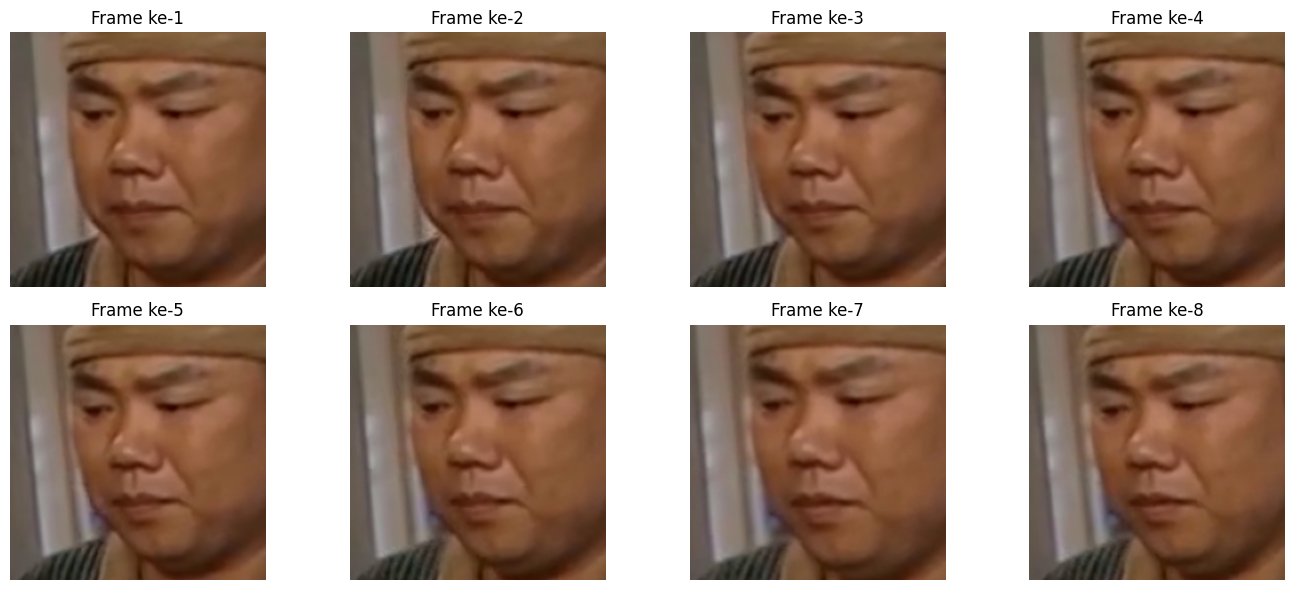

In [14]:
def denormalize_image(img_tensor, mean=NORM_MEAN, std=NORM_STD):
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    img = img * np.array(std) + np.array(mean)
    img = np.clip(img, 0, 1)
    return img

first_clip = sample_clips[0]  # [T, C, H, W]
num_show = min(8, first_clip.shape[0])

fig, axes = plt.subplots(2, math.ceil(num_show / 2), figsize=(14, 6))
axes = np.array(axes).reshape(-1)

for i in range(num_show):
    axes[i].imshow(denormalize_image(first_clip[i]))
    axes[i].set_title(f"Frame ke-{i+1}")
    axes[i].axis("off")

for i in range(num_show, len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

### 15. Focal Loss

In [15]:
class FocalLoss(nn.Module):
    """
    Focal Loss untuk klasifikasi multi-class berbasis logits.

    Pada notebook ini:
    - logits: [B, 2]
    - label : 0 = real, 1 = fake

    Rumus umum:
        FL = -alpha_t * (1 - p_t)^gamma * log(p_t)
    """

    def __init__(self, gamma: float = 2.0, alpha=None, reduction: str = "mean"):
        super().__init__()

        if gamma < 0:
            raise ValueError("gamma harus bernilai >= 0.")

        if reduction not in {"mean", "sum", "none"}:
            raise ValueError("reduction harus salah satu dari: 'mean', 'sum', atau 'none'.")

        self.gamma = gamma
        self.reduction = reduction

        if alpha is None:
            self.alpha = None
        else:
            alpha = torch.as_tensor(alpha, dtype=torch.float32)
            self.register_buffer("alpha", alpha)

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        targets = targets.long()

        log_probs = torch.log_softmax(logits, dim=1)
        probs = torch.exp(log_probs)

        target_indices = targets.unsqueeze(1)

        log_pt = log_probs.gather(1, target_indices).squeeze(1)
        pt = probs.gather(1, target_indices).squeeze(1)

        focal_factor = (1.0 - pt).pow(self.gamma)
        loss = -focal_factor * log_pt

        if self.alpha is not None:
            alpha_t = self.alpha.gather(0, targets)
            loss = alpha_t * loss

        if self.reduction == "mean":
            return loss.mean()

        if self.reduction == "sum":
            return loss.sum()

        return loss

### 16. Linear Decay Scheduler

In [16]:
class LinearDecayLR(_LRScheduler):
    def __init__(self, optimizer, n_epoch, start_decay, last_epoch=-1, booster=2):
        self.start_decay = start_decay
        self.n_epoch = n_epoch
        self.booster = booster
        super(LinearDecayLR, self).__init__(optimizer, last_epoch)

    def get_lr(self):
        last_epoch = self.last_epoch
        n_epoch = self.n_epoch
        b_lr = self.base_lrs[-1]

        if last_epoch > 0:
            try:
                cur_lr = self.get_last_lr()
            except Exception:
                cur_lr = b_lr * self.booster

        start_decay = self.start_decay

        if last_epoch >= start_decay:
            lr = b_lr * self.booster - (b_lr * self.booster) / (n_epoch - start_decay) * (last_epoch - start_decay)
        else:
            if last_epoch < start_decay:
                lr = b_lr + (b_lr * self.booster - b_lr) / start_decay * last_epoch
            else:
                lr = cur_lr

        self._last_lr = [lr]
        print(f"Active Learning Rate --- {lr}")
        return [lr for _ in self.optimizer.param_groups]

### 17. Model, Loss, Optimizer, Scheduler

In [17]:
model = timm.create_model(
    MODEL_NAME,
    pretrained=True,
    num_classes=2,
    img_size=CFG.final_image_size,

    # Dropout ablation
    drop_rate=DROPOUT_RATE,
    attn_drop_rate=ATTENTION_DROPOUT_RATE,
    drop_path_rate=DROP_PATH_RATE,
)

model = model.to(DEVICE)

print("ViT image size:", model.patch_embed.img_size)
print("ViT num patches:", model.patch_embed.num_patches)
model = model.to(DEVICE)

if USE_FOCAL_LOSS:
    if USE_FOCAL_ALPHA:
        class_counts_series = train_split_df["label"].astype(int).value_counts().sort_index()

        class_counts = torch.tensor(
            [
                class_counts_series.get(0, 0),
                class_counts_series.get(1, 0),
            ],
            dtype=torch.float32,
        )

        if torch.any(class_counts == 0):
            raise ValueError(
                f"Terdapat kelas dengan jumlah sampel 0 pada data latih: {class_counts.tolist()}"
            )

        focal_alpha = class_counts.sum() / (len(class_counts) * class_counts)
        focal_alpha = focal_alpha / focal_alpha.mean()

        print("Menggunakan Focal Loss dengan alpha otomatis.")
        print("Class counts [real, fake] :", class_counts.tolist())
        print("Focal alpha  [real, fake] :", focal_alpha.tolist())

    else:
        focal_alpha = None
        print("Menggunakan Focal Loss tanpa alpha.")

    criterion = FocalLoss(
        gamma=FOCAL_GAMMA,
        alpha=focal_alpha,
        reduction="mean",
    ).to(DEVICE)

else:
    criterion = nn.CrossEntropyLoss()
    print("Menggunakan CrossEntropyLoss.")


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

scheduler = LinearDecayLR(
    optimizer=optimizer,
    n_epoch=EPOCHS,
    start_decay=SCHEDULER_START_DECAY,
    booster=SCHEDULER_BOOSTER,
)

scaler = torch.cuda.amp.GradScaler(enabled=USE_GRAD_SCALER)

print("Optimizer          :", optimizer.__class__.__name__)
print("Base learning rate :", LR)
print("Weight decay       :", WEIGHT_DECAY)
print("Scheduler          :", SCHEDULER_NAME)
print("Start decay epoch  :", SCHEDULER_START_DECAY)
print("Scheduler booster  :", SCHEDULER_BOOSTER)
print("Max active LR      :", LR * SCHEDULER_BOOSTER)
print("Loss aktif         :", criterion.__class__.__name__)

model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

ViT image size: (224, 224)
ViT num patches: 196
Menggunakan CrossEntropyLoss.
Active Learning Rate --- 0.0005
Optimizer          : AdamW
Base learning rate : 0.0005
Weight decay       : 0.0001
Scheduler          : LinearDecayLR
Start decay epoch  : 6
Scheduler booster  : 2
Max active LR      : 0.001
Loss aktif         : CrossEntropyLoss


### 18. Metrics

In [18]:
def compute_classification_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "recall_macro": recall_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "f1_macro": f1_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "precision_weighted": precision_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
        "recall_weighted": recall_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
        "f1_weighted": f1_score(
            y_true, y_pred, average="weighted", zero_division=0
        ),
        "cm": cm,
        "y_pred": y_pred,
        "classification_report_text": classification_report(
            y_true,
            y_pred,
            labels=[0, 1],
            target_names=["real", "fake"],
            digits=4,
            zero_division=0,
        ),
        "classification_report_dict": classification_report(
            y_true,
            y_pred,
            labels=[0, 1],
            target_names=["real", "fake"],
            digits=4,
            zero_division=0,
            output_dict=True,
        ),
    }

    return metrics

### 19. Train/Eval Functions

In [19]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    scaler,
    device,
    epoch: int | None = None,
    total_epochs: int | None = None,
 ):
    """
    Training dilakukan pada tingkat klip agar fair dengan model spasiotemporal.

    Alur:
    1. DataLoader mengeluarkan batch [B, T, C, H, W]
    2. Backbone ViT memproses frame-level: [B*T, C, H, W]
    3. Untuk loss:
       - logits tiap frame di-reshape menjadi [B, T, 2]
       - kemudian dirata-ratakan pada tingkat klip -> [B, 2]
       - loss dihitung terhadap label klip menggunakan criterion yang aktif

    4. Untuk keputusan prediksi akhir di evaluasi:
       - probabilitas tiap frame dirata-ratakan pada tingkat klip
    """
    model.train()

    running_loss = 0.0
    total_samples = 0
    all_y_true = []
    all_y_pred = []

    if epoch is not None and total_epochs is not None:
        desc = f"Train {epoch:02d}/{total_epochs}"
    else:
        desc = "Train"

    progress_bar = tqdm(
        loader,
        desc=desc,
        total=len(loader),
        dynamic_ncols=True,
        leave=False,
    )

    for batch_idx, (clips, labels, meta) in enumerate(progress_bar, start=1):
        batch_start = time.time()
        b, t, c, h, w = clips.shape

        clips = clips.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        frames = clips.reshape(b * t, c, h, w)

        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=DEVICE.type, dtype=AMP_DTYPE, enabled=USE_AMP):
            frame_logits = model(frames)
            clip_logits = frame_logits.view(b, t, 2).mean(dim=1)
            loss = criterion(clip_logits, labels)
            preds = torch.argmax(clip_logits.detach().float(), dim=1)
            all_y_true.extend(labels.detach().cpu().numpy().tolist())
            all_y_pred.extend(preds.detach().cpu().numpy().tolist())

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * labels.size(0)
        total_samples += labels.size(0)

        avg_loss = running_loss / max(total_samples, 1)
        batch_time = time.time() - batch_start
        progress_bar.set_postfix({
            "loss": f"{avg_loss:.4f}",
            "batch_s": f"{batch_time:.1f}",
        })

        del clips, labels, frames, frame_logits, clip_logits, loss

    train_metrics = compute_classification_metrics(all_y_true, all_y_pred)
    train_metrics["loss"] = running_loss / max(total_samples, 1)

    return train_metrics


@torch.no_grad()
def evaluate_clip_level(
    model,
    loader,
    criterion,
    device,
    epoch: int | None = None,
    total_epochs: int | None = None,
 ):
    model.eval()

    running_loss = 0.0
    total_samples = 0

    all_y_true = []
    all_y_pred = []
    all_probs = []
    all_clip_dirs = []

    if epoch is not None and total_epochs is not None:
        desc = f"Valid {epoch:02d}/{total_epochs}"
    else:
        desc = "Valid"

    progress_bar = tqdm(
        loader,
        desc=desc,
        total=len(loader),
        dynamic_ncols=True,
        leave=False,
    )

    for batch_idx, (clips, labels, meta) in enumerate(progress_bar, start=1):
        batch_start = time.time()
        b, t, c, h, w = clips.shape

        clips = clips.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        frames = clips.reshape(b * t, c, h, w)

        with torch.autocast(device_type=DEVICE.type, dtype=AMP_DTYPE, enabled=USE_AMP):
            frame_logits = model(frames)
            clip_logits = frame_logits.view(b, t, 2).mean(dim=1)
            loss = criterion(clip_logits, labels)

        clip_probs = torch.softmax(clip_logits.float(), dim=1)
        preds = torch.argmax(clip_probs, dim=1)

        y_true = labels.detach().cpu().numpy()
        y_pred = preds.detach().cpu().numpy()
        prob_np = clip_probs.detach().cpu().numpy()

        all_y_true.extend(y_true.tolist())
        all_y_pred.extend(y_pred.tolist())
        all_probs.append(prob_np)
        all_clip_dirs.extend(meta["clip_dir"])

        running_loss += loss.item() * labels.size(0)
        total_samples += labels.size(0)

        avg_loss = running_loss / max(total_samples, 1)
        batch_time = time.time() - batch_start
        progress_bar.set_postfix({
            "val_loss": f"{avg_loss:.4f}",
            "batch_s": f"{batch_time:.1f}",
        })

        del clips, labels, frames, frame_logits, clip_logits, clip_probs, loss

    all_probs = np.concatenate(all_probs, axis=0)

    metric_dict = compute_classification_metrics(all_y_true, all_y_pred)
    metric_dict["loss"] = running_loss / max(total_samples, 1)
    metric_dict["y_true"] = np.array(all_y_true)
    metric_dict["y_pred"] = np.array(all_y_pred)
    metric_dict["y_prob_real"] = all_probs[:, 0]
    metric_dict["y_prob_fake"] = all_probs[:, 1]
    metric_dict["clip_dirs"] = all_clip_dirs

    return metric_dict

### 20. W&B Init

In [20]:
# INISIALISASI WEIGHTS & BIASES
wandb_run = None

def setup_wandb_login():
    if not USE_WANDB:
        return

    os.environ["WANDB_MODE"] = WANDB_MODE
    print(f"W&B mode: {os.environ['WANDB_MODE']}")


def build_wandb_config():
    return {
        "experiment_code": CFG.code,
        "experiment_description": CFG.description,
        "model_kind": MODEL_KIND,
        "num_classes": 2,
        "class_0": "real",
        "class_1": "fake",
        "source_clip_len": SOURCE_CLIP_LEN,
        "num_frames": CFG.num_frames,
        "stride": CFG.stride,
        "final_image_size": CFG.final_image_size,
        "downscale_first": CFG.downscale_first,
        "aug_geometry_oneof_prob": AUG_GEOMETRY_ONEOF_PROB,
        "aug_horizontal_flip": AUG_PROB_HFLIP,
        "aug_crop_limit": AUG_CROP_LIMIT,
        "aug_crop_prob": AUG_CROP_PROB,
        "aug_scale_limit": AUG_SCALE_LIMIT,
        "aug_scale_prob": AUG_SCALE_PROB,
        "aug_colorjitter_prob": AUG_COLORJITTER_PROB,
        "aug_colorjitter_brightness": AUG_COLORJITTER_BRIGHTNESS,
        "aug_colorjitter_contrast": AUG_COLORJITTER_CONTRAST,
        "aug_colorjitter_saturation": AUG_COLORJITTER_SATURATION,
        "aug_colorjitter_hue": AUG_COLORJITTER_HUE,
        "aug_blur_or_noise_oneof_prob": AUG_BLUR_OR_NOISE_ONEOF_PROB,
        "aug_gaussian_blur_prob": AUG_GAUSSIAN_BLUR_PROB,
        "aug_gaussian_blur_limit": AUG_GAUSSIAN_BLUR_LIMIT,
        "aug_gaussnoise_prob": AUG_GAUSSNOISE_PROB,
        "aug_gaussnoise_var_limit": AUG_GAUSSNOISE_VAR_LIMIT,
        "batch_size_clips": BATCH_SIZE_CLIPS,
        "epochs": EPOCHS,
        "learning_rate": LR,
        "weight_decay": WEIGHT_DECAY,
        "dropout_rate": DROPOUT_RATE,
        "attention_dropout_rate": ATTENTION_DROPOUT_RATE,
        "drop_path_rate": DROP_PATH_RATE,
        "optimizer": optimizer.__class__.__name__,
        "scheduler": SCHEDULER_NAME,
        "scheduler_start_decay": SCHEDULER_START_DECAY,
        "scheduler_booster": SCHEDULER_BOOSTER,
        "base_learning_rate": LR,
        "max_active_learning_rate": LR * SCHEDULER_BOOSTER,
        "use_early_stopping": USE_EARLY_STOPPING,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE if USE_EARLY_STOPPING else None,
        "loss_name": criterion.__class__.__name__,
        "use_focal_loss": USE_FOCAL_LOSS,
        "focal_gamma": FOCAL_GAMMA if USE_FOCAL_LOSS else None,
        "use_focal_alpha": USE_FOCAL_ALPHA if USE_FOCAL_LOSS else None,
        "train_size": len(train_dataset),
        "val_size": len(val_dataset),
        "test_size": len(test_dataset),
        "normalization_mean": NORM_MEAN,
        "normalization_std": NORM_STD,
        "checkpoint_selected_by": "val_accuracy",
        "evaluation_level": "clip_level",
    }


if USE_WANDB:
    setup_wandb_login()

    if wandb.run is not None:
        wandb.finish()

    wandb_run = wandb.init(
        project=WANDB_PROJECT,
        entity=WANDB_ENTITY,
        name=WANDB_RUN_NAME,
        group=WANDB_GROUP,
        tags=WANDB_TAGS,
        config=build_wandb_config(),
        dir=str(OUTPUT_DIR),
        reinit=True,
    )

    wandb_run.define_metric("epoch")
    wandb_run.define_metric("train/*", step_metric="epoch")
    wandb_run.define_metric("valid/*", step_metric="epoch")
    wandb_run.define_metric("lr", step_metric="epoch")
    wandb_run.define_metric("time/*", step_metric="epoch")
    wandb_run.define_metric("test/*")

    print("W&B run aktif:", wandb_run.name)
else:
    print("W&B dinonaktifkan.")

W&B mode: online


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: afenmarbun (afenmarbun-institut-teknologi-sumatera) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


W&B run aktif: E01_spatial_vit_vit_base_patch16_224.mae


### 21. Training Loop & Checkpoint

In [21]:
history = []
best_state = None
best_epoch = 0
best_val_accuracy = float("-inf")
patience_counter = 0

checkpoint_path = OUTPUT_DIR / f"best_{CFG.code}_spatial_vit.pt"

start_time = time.time()

print("Mulai training...", flush=True)
print("Experiment code :", CFG.code, flush=True)
print("Device          :", DEVICE, flush=True)
print("Checkpoint path :", checkpoint_path, flush=True)
print("Jumlah epoch    :", EPOCHS, flush=True)
print("Train batches   :", len(train_loader), flush=True)
print("Valid batches   :", len(val_loader), flush=True)

epoch_bar = tqdm(
    range(1, EPOCHS + 1),
    desc=f"Training {CFG.code}",
    total=EPOCHS,
    dynamic_ncols=True,
 )

for epoch in epoch_bar:
    epoch_start = time.time()

    print(f"\n[{CFG.code}] Mulai epoch {epoch:02d}/{EPOCHS}", flush=True)

    train_result = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        scaler=scaler,
        device=DEVICE,
        epoch=epoch,
        total_epochs=EPOCHS,
    )

    train_loss = train_result["loss"]

    val_result = evaluate_clip_level(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=DEVICE,
        epoch=epoch,
        total_epochs=EPOCHS,
    )

    scheduler.step()

    epoch_time_sec = time.time() - epoch_start

    row = {
        "epoch": int(epoch),
        "train_loss": float(train_loss),
        "train_accuracy": float(train_result["accuracy"]),
        "train_precision_macro": float(train_result["precision_macro"]),
        "train_recall_macro": float(train_result["recall_macro"]),
        "train_f1_macro": float(train_result["f1_macro"]),
        "train_precision_weighted": float(train_result["precision_weighted"]),
        "train_recall_weighted": float(train_result["recall_weighted"]),
        "train_f1_weighted": float(train_result["f1_weighted"]),

        "val_loss": float(val_result["loss"]),
        "val_accuracy": float(val_result["accuracy"]),
        "val_precision_macro": float(val_result["precision_macro"]),
        "val_recall_macro": float(val_result["recall_macro"]),
        "val_f1_macro": float(val_result["f1_macro"]),
        "val_precision_weighted": float(val_result["precision_weighted"]),
        "val_recall_weighted": float(val_result["recall_weighted"]),
        "val_f1_weighted": float(val_result["f1_weighted"]),

        "lr": float(optimizer.param_groups[0]["lr"]),
        "epoch_time_sec": float(epoch_time_sec),
    }
    history.append(row)
    
    if wandb_run is not None:
        wandb_run.log(
            {
                "epoch": row["epoch"],

                "train/loss": row["train_loss"],
                "train/accuracy": row["train_accuracy"],
                "train/precision_macro": row["train_precision_macro"],
                "train/recall_macro": row["train_recall_macro"],
                "train/f1_macro": row["train_f1_macro"],
                "train/precision_weighted": row["train_precision_weighted"],
                "train/recall_weighted": row["train_recall_weighted"],
                "train/f1_weighted": row["train_f1_weighted"],

                "valid/loss": row["val_loss"],
                "valid/accuracy": row["val_accuracy"],
                "valid/precision_macro": row["val_precision_macro"],
                "valid/recall_macro": row["val_recall_macro"],
                "valid/f1_macro": row["val_f1_macro"],
                "valid/precision_weighted": row["val_precision_weighted"],
                "valid/recall_weighted": row["val_recall_weighted"],
                "valid/f1_weighted": row["val_f1_weighted"],

                "lr": row["lr"],
                "time/epoch_sec": row["epoch_time_sec"],
            },
            step=epoch,
        )

    epoch_bar.set_postfix({
        "train_loss": f"{train_loss:.4f}",
        "val_loss": f"{val_result['loss']:.4f}",
        "val_f1_macro": f"{val_result['f1_macro']:.4f}",
    })

    print(
        f"[{CFG.code}] Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"train_acc={train_result['accuracy']:.4f} | "
        f"train_f1_macro={train_result['f1_macro']:.4f} | "
        f"val_loss={val_result['loss']:.4f} | "
        f"val_acc={val_result['accuracy']:.4f} | "
        f"val_f1_macro={val_result['f1_macro']:.4f} | "
        f"epoch_time={epoch_time_sec/60:.2f} menit",
        flush=True,
    )

    current_val_accuracy = float(val_result["accuracy"])

    if current_val_accuracy > best_val_accuracy:
        best_val_accuracy = current_val_accuracy
        best_epoch = epoch
        patience_counter = 0
        
        model_state_cpu = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }

        best_state = {
            "epoch": int(epoch),
            "experiment_code": str(CFG.code),
            "experiment_config": dict(CFG.__dict__),
            "model_name": str(MODEL_NAME),
            "checkpoint_selected_by": "val_accuracy",

            "loss_name": str(criterion.__class__.__name__),
            "use_focal_loss": bool(USE_FOCAL_LOSS),
            "focal_gamma": float(FOCAL_GAMMA) if USE_FOCAL_LOSS else None,
            "use_focal_alpha": bool(USE_FOCAL_ALPHA) if USE_FOCAL_LOSS else None,

            "model_state_dict": model_state_cpu,
            
            "best_val_accuracy": float(val_result["accuracy"]),
            "best_val_loss": float(val_result["loss"]),
            "best_val_precision_macro": float(val_result["precision_macro"]),
            "best_val_recall_macro": float(val_result["recall_macro"]),
            "best_val_f1_macro": float(val_result["f1_macro"]),
            "best_val_precision_weighted": float(val_result["precision_weighted"]),
            "best_val_recall_weighted": float(val_result["recall_weighted"]),
            "best_val_f1_weighted": float(val_result["f1_weighted"]),
        }

        torch.save(best_state, checkpoint_path)
        
        if wandb_run is not None:
            wandb_run.summary["best_epoch"] = int(epoch)
            wandb_run.summary["best/val_accuracy"] = float(val_result["accuracy"])
            wandb_run.summary["best/val_loss"] = float(val_result["loss"])
            wandb_run.summary["best/val_precision_macro"] = float(val_result["precision_macro"])
            wandb_run.summary["best/val_recall_macro"] = float(val_result["recall_macro"])
            wandb_run.summary["best/val_f1_macro"] = float(val_result["f1_macro"])
            wandb_run.summary["best/val_precision_weighted"] = float(val_result["precision_weighted"])
            wandb_run.summary["best/val_recall_weighted"] = float(val_result["recall_weighted"])
            wandb_run.summary["best/val_f1_weighted"] = float(val_result["f1_weighted"])

        print(
            f"  -> checkpoint terbaik disimpan berdasarkan "
            f"val_accuracy={best_val_accuracy:.4f}: {checkpoint_path}",
            flush=True,
        )

    else:
        if USE_EARLY_STOPPING:
            patience_counter += 1

            print(
                f"  -> val_accuracy tidak membaik, "
                f"patience: {patience_counter}/{EARLY_STOPPING_PATIENCE}",
                flush=True,
            )

            if patience_counter >= EARLY_STOPPING_PATIENCE:
                print("\nEarly stopping aktif.", flush=True)
                break

        else:
            print(
                "  -> val_accuracy tidak membaik; early stopping dinonaktifkan, training tetap dilanjutkan.",
                flush=True,
            )

    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

total_time = time.time() - start_time
print(f"\nTraining selesai dalam {total_time/60:.2f} menit.", flush=True)
print(f"Best epoch: {best_epoch}", flush=True)
print(f"Best validation accuracy: {best_val_accuracy:.4f}", flush=True)

history_df = pd.DataFrame(history)

history_df = history_df[
    [
        "epoch",
        "train_loss",
        "train_accuracy",
        "train_precision_macro",
        "train_recall_macro",
        "train_f1_macro",
        "train_precision_weighted",
        "train_recall_weighted",
        "train_f1_weighted",

        "val_loss",
        "val_accuracy",
        "val_precision_macro",
        "val_recall_macro",
        "val_f1_macro",
        "val_precision_weighted",
        "val_recall_weighted",
        "val_f1_weighted",

        "lr",
        "epoch_time_sec",
    ]
]

history_df.to_csv(OUTPUT_DIR / "training_history.csv", index=False)

if wandb_run is not None:
    wandb_run.log(
        {
            "training/history_table": wandb.Table(dataframe=history_df)
        },
        step=int(history_df["epoch"].max()),
    )
    
display(history_df.tail())

Mulai training...
Experiment code : E01
Device          : cuda
Checkpoint path : /workspace/experiments/spatial_vit/E01/best_E01_spatial_vit.pt
Jumlah epoch    : 25
Train batches   : 485
Valid batches   : 112


Training E01:   0% 0/25 [00:00<?, ?it/s]


[E01] Mulai epoch 01/25


Train 01/25:   0% 0/485 [00:06<?, ?it/s]

Valid 01/25:   0% 0/112 [00:00<?, ?it/s]

...

Active Learning Rate --- 5.2631578947368376e-05
[E01] Epoch 24 | train_loss=0.5195 | train_acc=0.7231 | train_f1_macro=0.6598 | val_loss=0.5870 | val_acc=0.6889 | val_f1_macro=0.6645 | epoch_time=2.94 menit
  -> checkpoint terbaik disimpan berdasarkan val_accuracy=0.6889: /workspace/experiments/spatial_vit/E01/best_E01_spatial_vit.pt

[E01] Mulai epoch 25/25


Train 25/25:   0% 0/485 [00:00<?, ?it/s]

Valid 25/25:   0% 0/112 [00:00<?, ?it/s]

Active Learning Rate --- 0.0
[E01] Epoch 25 | train_loss=0.5089 | train_acc=0.7350 | train_f1_macro=0.6753 | val_loss=0.6001 | val_acc=0.6948 | val_f1_macro=0.6646 | epoch_time=2.92 menit
  -> checkpoint terbaik disimpan berdasarkan val_accuracy=0.6948: /workspace/experiments/spatial_vit/E01/best_E01_spatial_vit.pt

Training selesai dalam 103.04 menit.
Best epoch: 25
Best validation accuracy: 0.6948


,epoch,train_loss,train_accuracy,train_precision_macro,train_recall_macro,train_f1_macro,train_precision_weighted,train_recall_weighted,train_f1_weighted,val_loss,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,val_precision_weighted,val_recall_weighted,val_f1_weighted,lr,epoch_time_sec
20,21,0.533690,0.710387,0.682421,0.635623,0.641336,0.697418,0.710387,0.689543,0.613361,0.678521,0.658618,0.650149,0.652740,0.672720,0.678521,0.674123,0.000211,174.767927
21,22,0.528314,0.719161,0.694130,0.647574,0.654701,0.707876,0.719161,0.700402,0.596294,0.680762,0.665669,0.668783,0.666879,0.684378,0.680762,0.682247,0.000158,174.658776
22,23,0.522349,0.722968,0.700094,0.651055,0.658607,0.712560,0.722968,0.704013,0.619119,0.684962,0.665908,0.658337,0.660859,0.679925,0.684962,0.681291,0.000105,175.808820
23,24,0.519509,0.723097,0.699675,0.652201,0.659843,0.712576,0.723097,0.704775,0.587019,0.688883,0.670190,0.661802,0.664537,0.683695,0.688883,0.684960,0.000053,176.129043
24,25,0.508858,0.735032,0.716389,0.666136,0.675279,0.726742,0.735032,0.717948,0.600122,0.694763,0.677301,0.660730,0.664594,0.687857,0.694763,0.687327,0.000000,174.946774


### 22. Training Curves

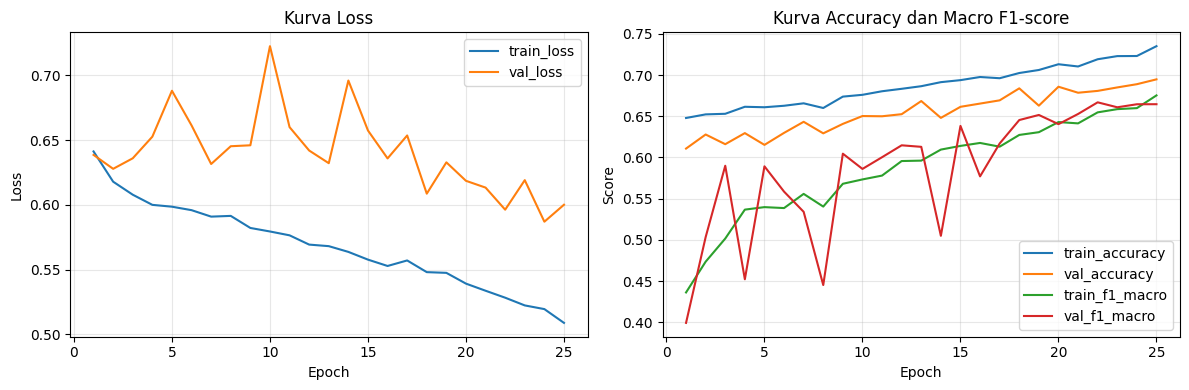

Plot history disimpan: /workspace/experiments/spatial_vit/E01/training_history.png


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
axes[0].set_title("Kurva Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_df["epoch"], history_df["train_accuracy"], label="train_accuracy")
axes[1].plot(history_df["epoch"], history_df["val_accuracy"], label="val_accuracy")
axes[1].plot(history_df["epoch"], history_df["train_f1_macro"], label="train_f1_macro")
axes[1].plot(history_df["epoch"], history_df["val_f1_macro"], label="val_f1_macro")
axes[1].set_title("Kurva Accuracy dan Macro F1-score")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

history_plot_path = OUTPUT_DIR / "training_history.png"
plt.savefig(history_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("Plot history disimpan:", history_plot_path)

### 23. Training Summary

In [23]:
if best_state is None:
    raise RuntimeError(
        "best_state masih None. Artinya belum ada checkpoint yang berhasil disimpan."
    )

summary_df = pd.DataFrame([{
    "experiment_code": CFG.code,
    "experiment_description": CFG.description,
    "model_name": MODEL_NAME,
    "checkpoint_path": str(checkpoint_path),
    "num_frames": CFG.num_frames,
    "stride": CFG.stride,
    "final_image_size": CFG.final_image_size,
    "downscale_first": CFG.downscale_first,
    "batch_size_clips": BATCH_SIZE_CLIPS,
    "checkpoint_selected_by": best_state.get("checkpoint_selected_by", "val_accuracy"),
    "loss_name": best_state.get("loss_name", criterion.__class__.__name__),
    "use_focal_loss": best_state.get("use_focal_loss", USE_FOCAL_LOSS),
    "focal_gamma": best_state.get("focal_gamma", FOCAL_GAMMA if USE_FOCAL_LOSS else None),
    "use_focal_alpha": best_state.get("use_focal_alpha", USE_FOCAL_ALPHA if USE_FOCAL_LOSS else None),
    "best_epoch": best_state["epoch"],
    "best_val_accuracy": best_state["best_val_accuracy"],
    "best_val_loss": best_state["best_val_loss"],
    "best_val_precision_macro": best_state["best_val_precision_macro"],
    "best_val_recall_macro": best_state["best_val_recall_macro"],
    "best_val_f1_macro": best_state["best_val_f1_macro"],
    "best_val_precision_weighted": best_state["best_val_precision_weighted"],
    "best_val_recall_weighted": best_state["best_val_recall_weighted"],
    "best_val_f1_weighted": best_state["best_val_f1_weighted"],
}])

training_summary_path = OUTPUT_DIR / "training_summary.csv"
summary_df.to_csv(training_summary_path, index=False)

if wandb_run is not None:
    wandb_run.log({
        "training/summary_table": wandb.Table(dataframe=summary_df)
    })

print("Training summary disimpan:", training_summary_path)
display(summary_df)

Training summary disimpan: /workspace/experiments/spatial_vit/E01/training_summary.csv


,experiment_code,experiment_description,model_name,checkpoint_path,num_frames,stride,final_image_size,downscale_first,batch_size_clips,checkpoint_selected_by,...,use_focal_alpha,best_epoch,best_val_accuracy,best_val_loss,best_val_precision_macro,best_val_recall_macro,best_val_f1_macro,best_val_precision_weighted,best_val_recall_weighted,best_val_f1_weighted
0,E01,Konfigurasi dasar,vit_base_patch16_224.mae,/workspace/experiments/spatial_vit/E01/best_E0...,16,3,224,None,32,val_accuracy,...,None,25,0.694763,0.600122,0.677301,0.66073,0.664594,0.687857,0.694763,0.687327


### 24. Final Test Evaluation

In [24]:
# FINAL TESTING PADA DATA TEST
test_output_dir = OUTPUT_DIR / "test_results"
test_output_dir.mkdir(parents=True, exist_ok=True)
checkpoint_path = OUTPUT_DIR / f"best_{CFG.code}_spatial_vit.pt"

if not checkpoint_path.exists():
    raise FileNotFoundError(
        f"Checkpoint terbaik tidak ditemukan: {checkpoint_path}\n"
        "Pastikan cell training sudah dijalankan sampai checkpoint tersimpan."
    )

print("Memuat checkpoint terbaik:")
print(checkpoint_path)

try:
    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
        weights_only=False,
    )
except TypeError:
    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
    )

model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(DEVICE)
model.eval()

print("\nInformasi checkpoint:")
print("Experiment code       :", checkpoint.get("experiment_code"))
print("Best epoch            :", checkpoint.get("epoch"))
print("Selected by           :", checkpoint.get("checkpoint_selected_by"))
print("Best val accuracy     :", checkpoint.get("best_val_accuracy"))
print("Best val F1 macro     :", checkpoint.get("best_val_f1_macro"))
print("Best val precision macro:", checkpoint.get("best_val_precision_macro"))
print("Best val recall macro :", checkpoint.get("best_val_recall_macro"))
print("\nMulai evaluasi pada data test...")

test_result = evaluate_clip_level(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=DEVICE,
)

test_metrics = {
    "experiment_code": CFG.code,
    "description": CFG.description,
    "checkpoint_path": str(checkpoint_path),
    "best_epoch": int(checkpoint.get("epoch")),
    "checkpoint_selected_by": checkpoint.get("checkpoint_selected_by"),
    "test_loss": float(test_result["loss"]),
    "test_accuracy": float(test_result["accuracy"]),
    "test_precision_macro": float(test_result["precision_macro"]),
    "test_recall_macro": float(test_result["recall_macro"]),
    "test_f1_macro": float(test_result["f1_macro"]),
    "test_precision_weighted": float(test_result["precision_weighted"]),
    "test_recall_weighted": float(test_result["recall_weighted"]),
    "test_f1_weighted": float(test_result["f1_weighted"]),
}

print("\n HASIL FINAL TEST : ")
print(f"Test loss                : {test_metrics['test_loss']:.4f}")
print(f"Test accuracy            : {test_metrics['test_accuracy']:.4f}")
print(f"Test precision macro     : {test_metrics['test_precision_macro']:.4f}")
print(f"Test recall macro        : {test_metrics['test_recall_macro']:.4f}")
print(f"Test F1-score macro      : {test_metrics['test_f1_macro']:.4f}")
print(f"Test precision weighted  : {test_metrics['test_precision_weighted']:.4f}")
print(f"Test recall weighted     : {test_metrics['test_recall_weighted']:.4f}")
print(f"Test F1-score weighted   : {test_metrics['test_f1_weighted']:.4f}")

print("\nConfusion Matrix")
print("Baris  : label aktual [real, fake]")
print("Kolom  : label prediksi [real, fake]")
print(test_result["cm"])


# SIMPAN METRIK TEST
test_metrics_csv_path = test_output_dir / "test_metrics.csv"
test_metrics_json_path = test_output_dir / "test_metrics.json"

pd.DataFrame([test_metrics]).to_csv(test_metrics_csv_path, index=False)
with open(test_metrics_json_path, "w", encoding="utf-8") as f:
    json.dump(test_metrics, f, indent=2)


# SIMPAN PREDIKSI PER KLIP

test_pred_df = pd.DataFrame({
    "clip_dir": test_result["clip_dirs"],
    "y_true": test_result["y_true"].astype(int),
    "y_pred": test_result["y_pred"].astype(int),
    "y_prob_real": test_result["y_prob_real"].astype(float),
    "y_prob_fake": test_result["y_prob_fake"].astype(float),
})

test_pred_df["y_true_label"] = test_pred_df["y_true"].map(IDX_TO_CLASS)
test_pred_df["y_pred_label"] = test_pred_df["y_pred"].map(IDX_TO_CLASS)
test_pred_df["is_correct"] = test_pred_df["y_true"] == test_pred_df["y_pred"]

classification_report_df = pd.DataFrame(test_result["classification_report_dict"]).T
classification_report_path = test_output_dir / "test_classification_report.csv"
classification_report_df.to_csv(classification_report_path)

if wandb_run is not None:
    wandb_run.log({
        "test/classification_report": wandb.Table(
            dataframe=classification_report_df.reset_index()
        )
    })

print("Classification report:", classification_report_path)
print("\nClassification Report")
print(test_result["classification_report_text"])

test_predictions_csv_path = test_output_dir / "test_predictions_clip_level.csv"
test_pred_df.to_csv(test_predictions_csv_path, index=False)

if wandb_run is not None:
    wandb_run.log({
        "test/predictions_clip_level_sample": wandb.Table(
            dataframe=test_pred_df.head(1000)
        )
    })

print("\nFile hasil testing disimpan:")
print("Metrik CSV       :", test_metrics_csv_path)
print("Metrik JSON      :", test_metrics_json_path)
print("Prediksi per klip:", test_predictions_csv_path)

display(test_pred_df.head())

Memuat checkpoint terbaik:
/workspace/experiments/spatial_vit/E01/best_E01_spatial_vit.pt

Informasi checkpoint:
Experiment code       : E01
Best epoch            : 25
Selected by           : val_accuracy
Best val accuracy     : 0.6947633716045926
Best val F1 macro     : 0.6645937096079275
Best val precision macro: 0.6773008772435198
Best val recall macro : 0.6607298100818525

Mulai evaluasi pada data test...


Valid:   0% 0/101 [00:10<?, ?it/s]


 HASIL FINAL TEST : 
Test loss                : 0.6841
Test accuracy            : 0.6417
Test precision macro     : 0.5910
Test recall macro        : 0.5848
Test F1-score macro      : 0.5866
Test precision weighted  : 0.6314
Test recall weighted     : 0.6417
Test F1-score weighted   : 0.6355

Confusion Matrix
Baris  : label aktual [real, fake]
Kolom  : label prediksi [real, fake]
[[ 447  646]
 [ 512 1627]]
Classification report: /workspace/experiments/spatial_vit/E01/test_results/test_classification_report.csv

Classification Report
              precision    recall  f1-score   support

        real     0.4661    0.4090    0.4357      1093
        fake     0.7158    0.7606    0.7375      2139

    accuracy                         0.6417      3232
   macro avg     0.5910    0.5848    0.5866      3232
weighted avg     0.6314    0.6417    0.6355      3232


File hasil testing disimpan:
Metrik CSV       : /workspace/experiments/spatial_vit/E01/test_results/test_metrics.csv
Metrik JSON    

,clip_dir,y_true,y_pred,y_prob_real,y_prob_fake,y_true_label,y_pred_label,is_correct
0,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...,0,0,0.677901,0.322099,real,real,True
1,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...,0,0,0.530419,0.469581,real,real,True
2,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...,0,0,0.685949,0.314051,real,real,True
3,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...,0,1,0.457379,0.542621,real,fake,False
4,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...,0,0,0.660610,0.339390,real,real,True


### 25. W&B Test Logging

In [25]:
if wandb_run is not None:
    wandb_run.log({
        "test/loss": test_metrics["test_loss"],
        "test/accuracy": test_metrics["test_accuracy"],
        "test/precision_macro": test_metrics["test_precision_macro"],
        "test/recall_macro": test_metrics["test_recall_macro"],
        "test/f1_macro": test_metrics["test_f1_macro"],
        "test/precision_weighted": test_metrics["test_precision_weighted"],
        "test/recall_weighted": test_metrics["test_recall_weighted"],
        "test/f1_weighted": test_metrics["test_f1_weighted"],
    })

    wandb_run.summary["test/loss"] = test_metrics["test_loss"]
    wandb_run.summary["test/accuracy"] = test_metrics["test_accuracy"]
    wandb_run.summary["test/precision_macro"] = test_metrics["test_precision_macro"]
    wandb_run.summary["test/recall_macro"] = test_metrics["test_recall_macro"]
    wandb_run.summary["test/f1_macro"] = test_metrics["test_f1_macro"]
    wandb_run.summary["test/precision_weighted"] = test_metrics["test_precision_weighted"]
    wandb_run.summary["test/recall_weighted"] = test_metrics["test_recall_weighted"]
    wandb_run.summary["test/f1_weighted"] = test_metrics["test_f1_weighted"]

### 26. Confusion Matrix Plot

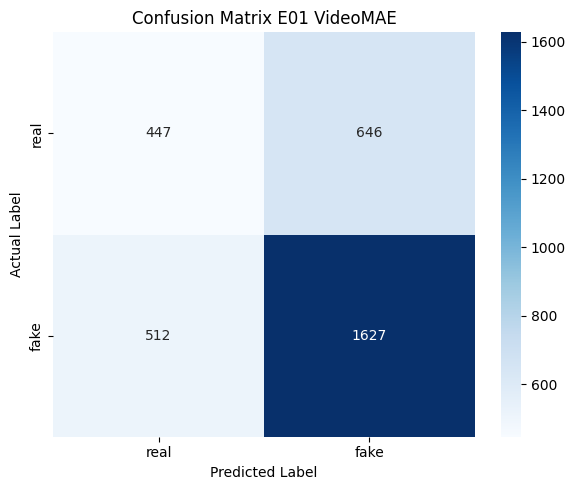

Confusion matrix disimpan: /workspace/experiments/spatial_vit/E01/test_results/test_confusion_matrix.png


In [26]:
# VISUALISASI HASIL TESTING

cm = test_result["cm"]
class_names = [IDX_TO_CLASS[i] for i in sorted(IDX_TO_CLASS.keys())]  # ["real", "fake"]

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(f"Confusion Matrix {CFG.code} VideoMAE")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.tight_layout()

confusion_matrix_path = test_output_dir / "test_confusion_matrix.png"
plt.savefig(confusion_matrix_path, dpi=200, bbox_inches="tight")
plt.show()

if wandb_run is not None:
    wandb_run.log({
        "test/confusion_matrix": wandb.Image(str(confusion_matrix_path))
    })

print("Confusion matrix disimpan:", confusion_matrix_path)

### 27. Misclassified Analysis

In [27]:
# ANALISIS SAMPEL YANG SALAH PREDIKSI

misclassified_df = test_pred_df[test_pred_df["is_correct"] == False].copy()

print("Jumlah seluruh klip test       :", len(test_pred_df))
print("Jumlah salah prediksi          :", len(misclassified_df))
print("Persentase salah prediksi (%)  :", 100 * len(misclassified_df) / max(len(test_pred_df), 1))

display(
    misclassified_df.sort_values(
        by="y_prob_fake",
        ascending=False,
    ).head(30)
)

misclassified_csv_path = test_output_dir / "test_misclassified_clip_level.csv"
misclassified_df.to_csv(misclassified_csv_path, index=False)

print("Data salah prediksi disimpan:", misclassified_csv_path)

Jumlah seluruh klip test       : 3232
Jumlah salah prediksi          : 1158
Persentase salah prediksi (%)  : 35.82920792079208


,clip_dir,y_true,y_pred,y_prob_real,y_prob_fake,y_true_label,y_pred_label,is_correct
449,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...,0,1,0.001755,0.998245,real,fake,False
1017,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...,0,1,0.001868,0.998132,real,fake,False
450,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...,0,1,0.003222,0.996777,real,fake,False
1016,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...,0,1,0.003483,0.996517,real,fake,False
452,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...,0,1,0.003538,0.996462,real,fake,False
396,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...,0,1,0.004070,0.995930,real,fake,False
451,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...,0,1,0.004610,0.995390,real,fake,False
872,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...,0,1,0.004905,0.995095,real,fake,False
446,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...,0,1,0.006193,0.993807,real,fake,False
395,/workspace/wdf46f_runtime/wilddeepfake-46f/wil...,0,1,0.008985,0.991015,real,fake,False


Data salah prediksi disimpan: /workspace/experiments/spatial_vit/E01/test_results/test_misclassified_clip_level.csv


### 28. Grad-CAM Visualization

Memuat checkpoint terbaik untuk Grad-CAM:
/workspace/experiments/spatial_vit/E01/best_E01_spatial_vit.pt
Checkpoint berhasil dimuat.
Best epoch        : 25
Best val accuracy : 0.6947633716045926
Grad-CAM ViT grid size: 14 x 14

Sampel test index : 0
Clip dir          : /workspace/wdf46f_runtime/wilddeepfake-46f/wilddeepfake_46f_merged_v5/real_test/104/10_0
Label aktual      : real
Prediksi model    : real
Prob(real)        : 0.6777
Prob(fake)        : 0.3223
Target Grad-CAM   : real
Sampled indices   : tensor([ 0,  3,  6,  9, 12, 15, 18, 21, 24, 27, 30, 33, 36, 39, 42, 45])


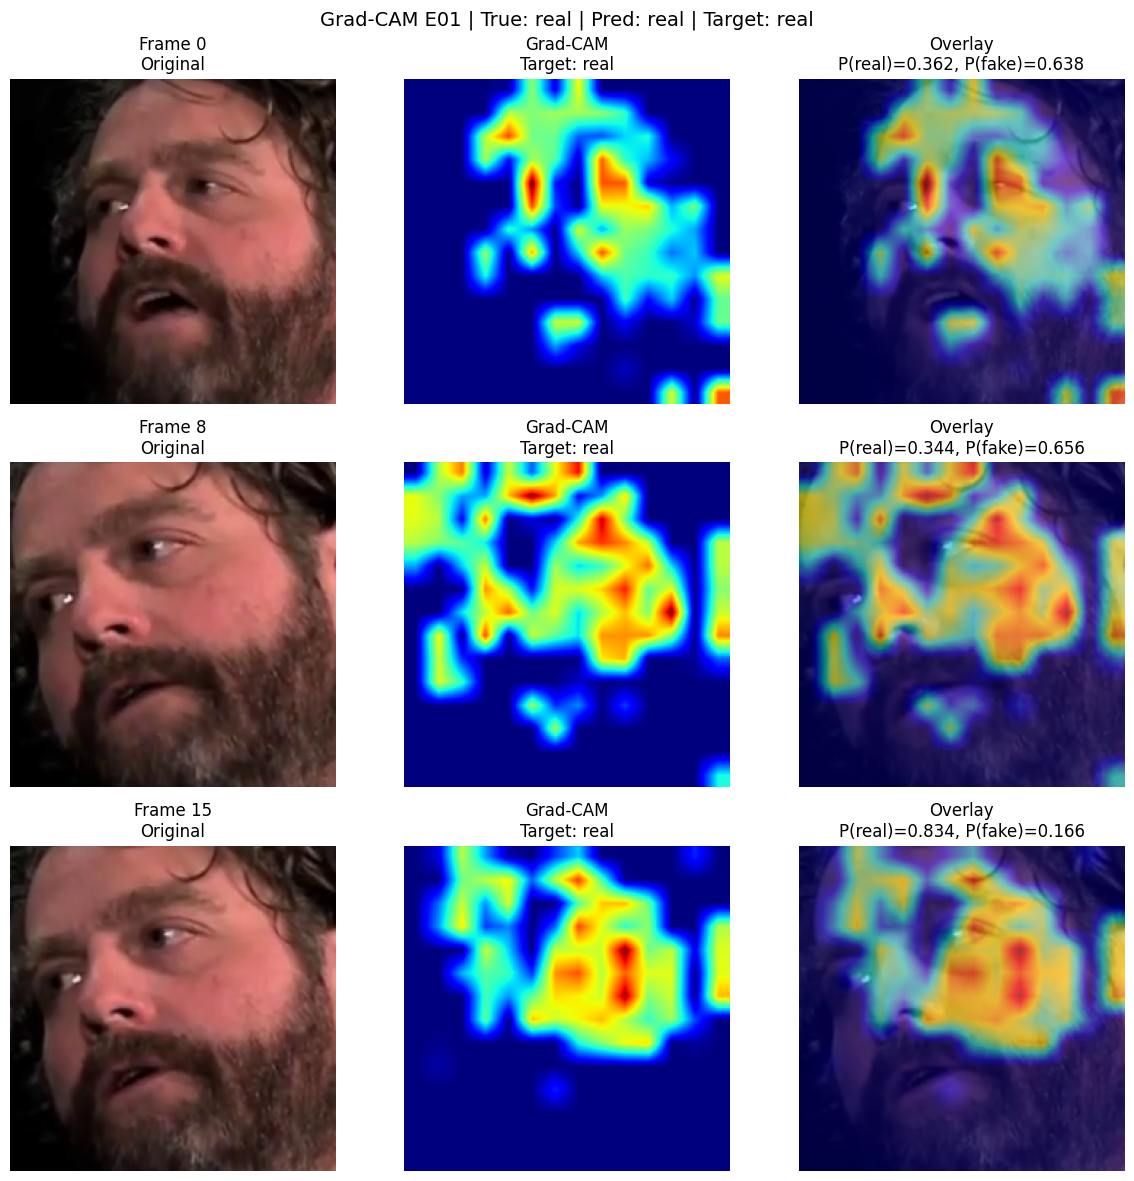

Grad-CAM sampel disimpan di: /workspace/experiments/spatial_vit/E01/gradcam_results/test_index_0000
Ringkasan gambar            : /workspace/experiments/spatial_vit/E01/gradcam_results/test_index_0000/gradcam_summary.png

Sampel test index : 1
Clip dir          : /workspace/wdf46f_runtime/wilddeepfake-46f/wilddeepfake_46f_merged_v5/real_test/104/10_1
Label aktual      : real
Prediksi model    : real
Prob(real)        : 0.5307
Prob(fake)        : 0.4693
Target Grad-CAM   : real
Sampled indices   : tensor([ 0,  3,  6,  9, 12, 15, 18, 21, 24, 27, 30, 33, 36, 39, 42, 45])


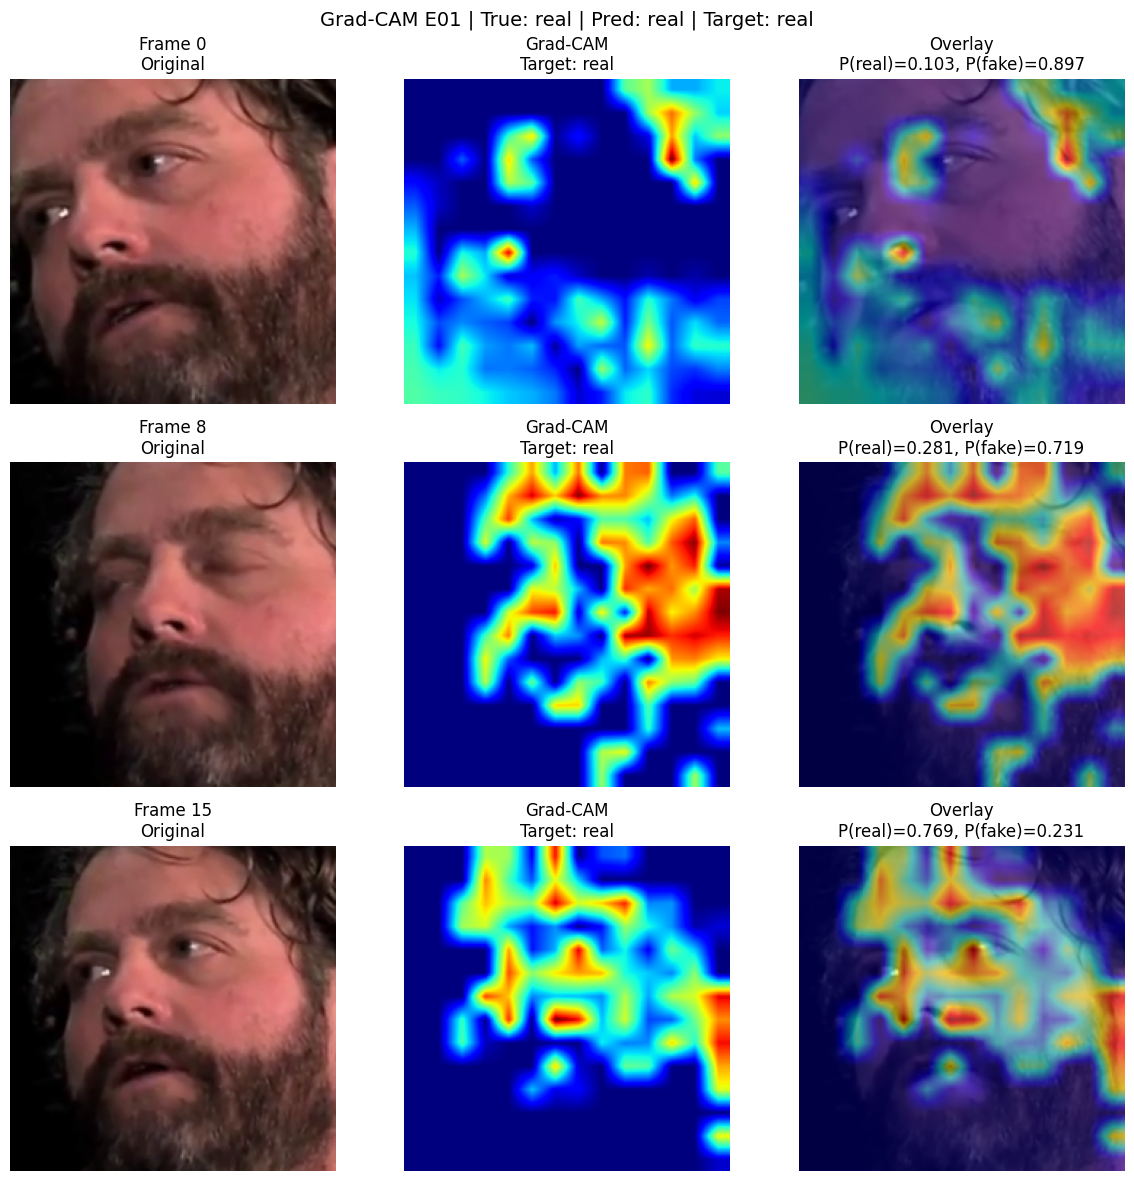

Grad-CAM sampel disimpan di: /workspace/experiments/spatial_vit/E01/gradcam_results/test_index_0001
Ringkasan gambar            : /workspace/experiments/spatial_vit/E01/gradcam_results/test_index_0001/gradcam_summary.png

Sampel test index : 2
Clip dir          : /workspace/wdf46f_runtime/wilddeepfake-46f/wilddeepfake_46f_merged_v5/real_test/104/13_0
Label aktual      : real
Prediksi model    : real
Prob(real)        : 0.6822
Prob(fake)        : 0.3178
Target Grad-CAM   : real
Sampled indices   : tensor([ 0,  3,  6,  9, 12, 15, 18, 21, 24, 27, 30, 33, 36, 39, 42, 45])


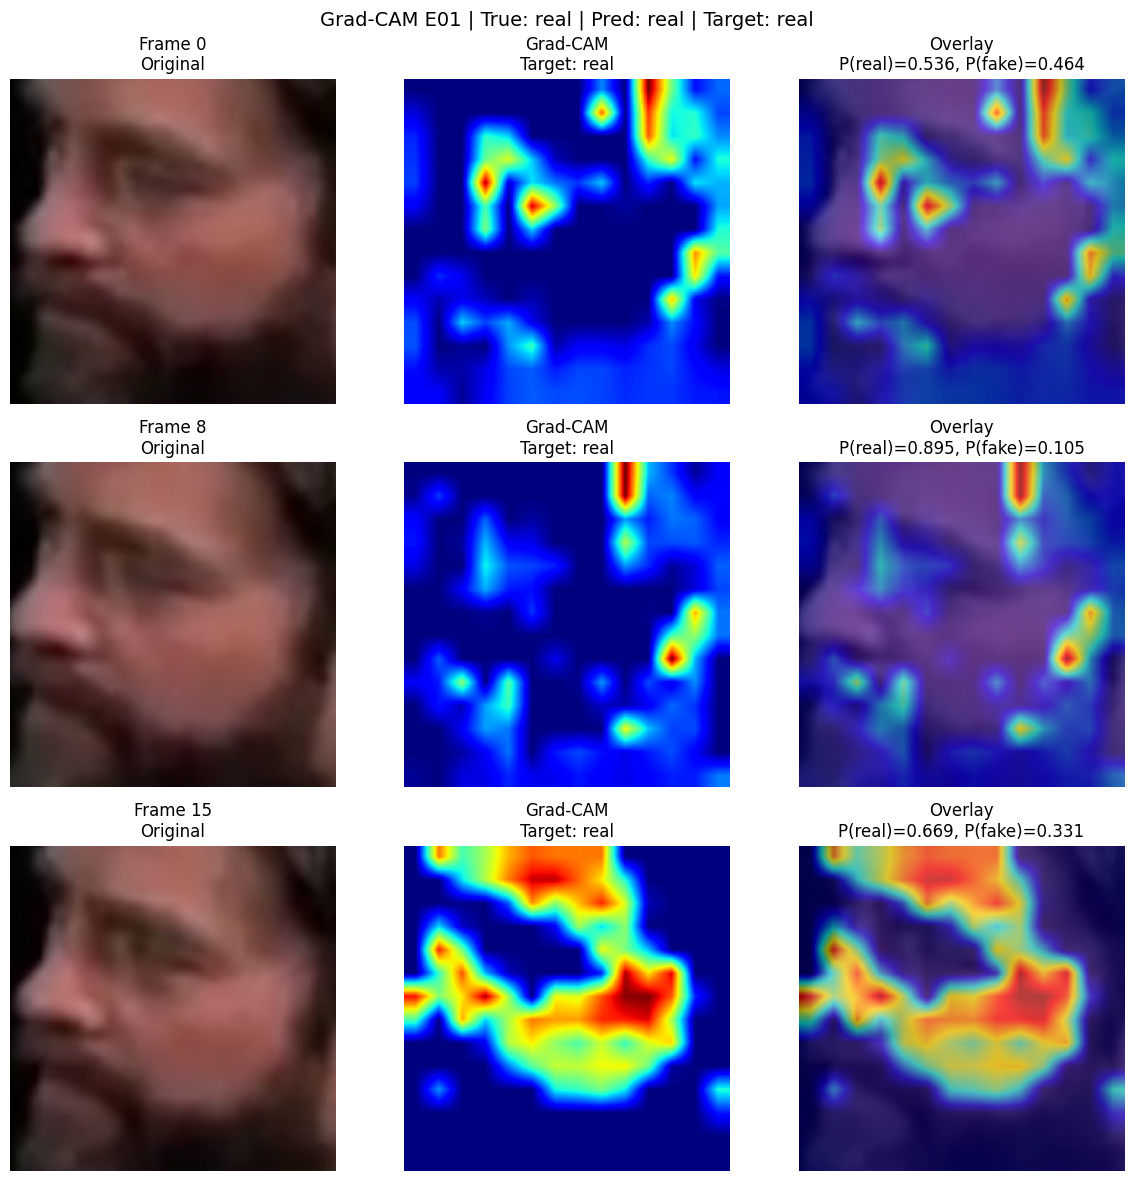

Grad-CAM sampel disimpan di: /workspace/experiments/spatial_vit/E01/gradcam_results/test_index_0002
Ringkasan gambar            : /workspace/experiments/spatial_vit/E01/gradcam_results/test_index_0002/gradcam_summary.png

Proses Grad-CAM selesai.
Folder output: /workspace/experiments/spatial_vit/E01/gradcam_results


In [28]:
# GRAD-CAM UNTUK MODEL SPASIAL VISION TRANSFORMER

gradcam_output_dir = OUTPUT_DIR / "gradcam_results"
gradcam_output_dir.mkdir(parents=True, exist_ok=True)

# Pilih indeks sampel dari test_dataset.
GRADCAM_SAMPLE_INDICES = [0, 1, 2]

# Pilih frame yang ingin divisualisasikan dari hasil sampling.
# Untuk E01 dengan 16 frame: frame 0, tengah, dan terakhir.
GRADCAM_FRAME_INDICES = sorted(set([
    0,
    CFG.num_frames // 2,
    CFG.num_frames - 1,
]))

# Pilihan target:
# - "predicted" : Grad-CAM mengikuti kelas prediksi model
# - "true"      : Grad-CAM mengikuti label aktual
# - "fake"      : Grad-CAM khusus untuk kelas fake
# - "real"      : Grad-CAM khusus untuk kelas real
GRADCAM_TARGET_MODE = "predicted"

# Smoothing membuat heatmap lebih halus, tetapi lebih lambat.
USE_AUG_SMOOTH = False
USE_EIGEN_SMOOTH = True


# MUAT CHECKPOINT TERBAIK
checkpoint_path = OUTPUT_DIR / f"best_{CFG.code}_spatial_vit.pt"
if not checkpoint_path.exists():
    raise FileNotFoundError(
        f"Checkpoint terbaik tidak ditemukan: {checkpoint_path}\n"
        "Jalankan training terlebih dahulu sampai checkpoint tersimpan."
    )

print("Memuat checkpoint terbaik untuk Grad-CAM:")
print(checkpoint_path)

try:
    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
        weights_only=False,
    )
except TypeError:
    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
    )

model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(DEVICE)
model.eval()

for param in model.parameters():
    param.requires_grad_(True)

print("Checkpoint berhasil dimuat.")
print("Best epoch        :", checkpoint.get("epoch"))
print("Best val accuracy :", checkpoint.get("best_val_accuracy"))


vit_grid_size = CFG.final_image_size // model.patch_embed.patch_size[0]

def vit_reshape_transform(tensor, height=vit_grid_size, width=vit_grid_size):
    result = tensor[:, 1:, :].reshape(
        tensor.size(0),
        height,
        width,
        tensor.size(2),
    )
    result = result.permute(0, 3, 1, 2)
    return result

print("Grad-CAM ViT grid size:", vit_grid_size, "x", vit_grid_size)


# Target layer untuk ViT.
# Untuk timm ViT, struktur umumnya memiliki model.blocks.
target_layers = [model.blocks[-1].norm1]

def get_clip_prediction_spatial_vit(model, clip_tensor, device):
    """
    Menghasilkan prediksi tingkat klip dari model spasial ViT.

    Input:
        clip_tensor: [T, C, H, W]

    Output:
        clip_prob  : probabilitas tingkat klip [2]
        frame_prob : probabilitas tiap frame [T, 2], hanya untuk informasi visual
        pred_class : kelas prediksi tingkat klip
    """
    model.eval()

    with torch.no_grad():
        frames = clip_tensor.to(device)          # [T, C, H, W]
        logits = model(frames)                  # [T, 2]

        clip_logits = logits.mean(dim=0)        # [2]
        clip_prob = torch.softmax(
            clip_logits.float(),
            dim=0,
        )

        frame_prob = torch.softmax(
            logits.float(),
            dim=1,
        )

        pred_class = int(torch.argmax(clip_prob).item())

    return (
        clip_prob.detach().cpu(),
        frame_prob.detach().cpu(),
        pred_class,
    )


def resolve_gradcam_target_class(mode, pred_class, true_class):
    """
    Menentukan kelas target Grad-CAM.
    """
    if mode == "predicted":
        return int(pred_class)

    if mode == "true":
        return int(true_class)

    if mode == "fake":
        return CLASS_TO_IDX["fake"]

    if mode == "real":
        return CLASS_TO_IDX["real"]

    raise ValueError(
        "GRADCAM_TARGET_MODE harus salah satu dari: "
        "'predicted', 'true', 'fake', atau 'real'."
    )


def make_gradcam_for_frame(
    model,
    frame_tensor,
    target_class,
    cam,
    device,
):
    """
    Membuat Grad-CAM untuk satu frame.

    Input:
        frame_tensor : [C, H, W]
        target_class : 0 real atau 1 fake

    Output:
        rgb_img       : citra RGB denormalisasi [0, 1]
        grayscale_cam : heatmap Grad-CAM [H, W]
        visualization : overlay heatmap pada citra asli
    """
    input_tensor = frame_tensor.unsqueeze(0).to(device)  # [1, C, H, W]

    targets = [ClassifierOutputTarget(target_class)]

    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets,
        aug_smooth=USE_AUG_SMOOTH,
        eigen_smooth=USE_EIGEN_SMOOTH,
    )

    grayscale_cam = grayscale_cam[0, :]

    rgb_img = denormalize_image(frame_tensor)
    visualization = show_cam_on_image(
        rgb_img.astype(np.float32),
        grayscale_cam,
        use_rgb=True,
    )

    return rgb_img, grayscale_cam, visualization


# PROSES GRAD-CAM
with GradCAM(
    model=model,
    target_layers=target_layers,
    reshape_transform=vit_reshape_transform,
) as cam:

    for sample_idx in GRADCAM_SAMPLE_INDICES:
        if sample_idx < 0 or sample_idx >= len(test_dataset):
            print(f"Indeks {sample_idx} dilewati karena di luar rentang test_dataset.")
            continue

        clip_tensor, label_tensor, meta = test_dataset[sample_idx]

        true_class = int(label_tensor.item())
        true_label = IDX_TO_CLASS[true_class]

        clip_prob, frame_prob, pred_class = get_clip_prediction_spatial_vit(
            model=model,
            clip_tensor=clip_tensor,
            device=DEVICE,
        )

        pred_label = IDX_TO_CLASS[pred_class]
        prob_real = float(clip_prob[CLASS_TO_IDX["real"]].item())
        prob_fake = float(clip_prob[CLASS_TO_IDX["fake"]].item())

        target_class = resolve_gradcam_target_class(
            mode=GRADCAM_TARGET_MODE,
            pred_class=pred_class,
            true_class=true_class,
        )
        target_label = IDX_TO_CLASS[target_class]

        print("\n=================================================")
        print(f"Sampel test index : {sample_idx}")
        print(f"Clip dir          : {meta['clip_dir']}")
        print(f"Label aktual      : {true_label}")
        print(f"Prediksi model    : {pred_label}")
        print(f"Prob(real)        : {prob_real:.4f}")
        print(f"Prob(fake)        : {prob_fake:.4f}")
        print(f"Target Grad-CAM   : {target_label}")
        print("Sampled indices   :", meta["sampled_indices"])

        valid_frame_indices = [
            i for i in GRADCAM_FRAME_INDICES
            if 0 <= i < clip_tensor.shape[0]
        ]

        fig, axes = plt.subplots(
            len(valid_frame_indices),
            3,
            figsize=(12, 4 * len(valid_frame_indices)),
        )

        if len(valid_frame_indices) == 1:
            axes = np.expand_dims(axes, axis=0)

        sample_save_dir = gradcam_output_dir / f"test_index_{sample_idx:04d}"
        sample_save_dir.mkdir(parents=True, exist_ok=True)

        for row_idx, frame_idx in enumerate(valid_frame_indices):
            frame_tensor = clip_tensor[frame_idx]

            rgb_img, grayscale_cam, visualization = make_gradcam_for_frame(
                model=model,
                frame_tensor=frame_tensor,
                target_class=target_class,
                cam=cam,
                device=DEVICE,
            )

            frame_prob_real = float(frame_prob[frame_idx, CLASS_TO_IDX["real"]].item())
            frame_prob_fake = float(frame_prob[frame_idx, CLASS_TO_IDX["fake"]].item())

            axes[row_idx, 0].imshow(rgb_img)
            axes[row_idx, 0].set_title(
                f"Frame {frame_idx}\nOriginal"
            )
            axes[row_idx, 0].axis("off")

            axes[row_idx, 1].imshow(grayscale_cam, cmap="jet")
            axes[row_idx, 1].set_title(
                f"Grad-CAM\nTarget: {target_label}"
            )
            axes[row_idx, 1].axis("off")

            axes[row_idx, 2].imshow(visualization)
            axes[row_idx, 2].set_title(
                f"Overlay\nP(real)={frame_prob_real:.3f}, P(fake)={frame_prob_fake:.3f}"
            )
            axes[row_idx, 2].axis("off")

            # Simpan hasil overlay per frame.
            overlay_path = sample_save_dir / (
                f"frame_{frame_idx:02d}_target_{target_label}_overlay.png"
            )
            heatmap_path = sample_save_dir / (
                f"frame_{frame_idx:02d}_target_{target_label}_heatmap.png"
            )
            original_path = sample_save_dir / (
                f"frame_{frame_idx:02d}_original.png"
            )

            Image.fromarray(visualization).save(overlay_path)

            heatmap_uint8 = np.uint8(255 * grayscale_cam)
            heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
            heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
            Image.fromarray(heatmap_color).save(heatmap_path)

            original_uint8 = np.uint8(255 * rgb_img)
            Image.fromarray(original_uint8).save(original_path)

        plt.suptitle(
            f"Grad-CAM {CFG.code} | "
            f"True: {true_label} | Pred: {pred_label} | Target: {target_label}",
            fontsize=14,
        )
        plt.tight_layout()

        figure_path = sample_save_dir / "gradcam_summary.png"
        plt.savefig(figure_path, dpi=200, bbox_inches="tight")
        plt.show()

        print("Grad-CAM sampel disimpan di:", sample_save_dir)
        print("Ringkasan gambar            :", figure_path)

print("\nProses Grad-CAM selesai.")
print("Folder output:", gradcam_output_dir)

### 29. Log W&B Artifact

In [29]:
# LOG ARTIFACT HASIL EKSPERIMEN KE W&B

def log_experiment_artifact_to_wandb():
    if wandb_run is None:
        return

    artifact_name = sanitize_wandb_name(f"{WANDB_RUN_NAME}_outputs")

    artifact = wandb.Artifact(
        name=artifact_name,
        type="experiment-output",
        metadata={
            "experiment_code": CFG.code,
            "model_kind": MODEL_KIND,
            "num_frames": CFG.num_frames,
            "stride": CFG.stride,
            "final_image_size": CFG.final_image_size,
            "checkpoint_selected_by": "val_accuracy",
        },
    )

    candidate_files = [
        checkpoint_path,
        OUTPUT_DIR / "training_history.csv",
        OUTPUT_DIR / "training_summary.csv",
        test_output_dir / "test_metrics.csv",
        test_output_dir / "test_metrics.json",
        test_output_dir / "test_predictions_clip_level.csv",
        test_output_dir / "test_classification_report.csv",
        test_output_dir / "test_confusion_matrix.png",
        test_output_dir / "test_misclassified_clip_level.csv",
    ]

    for file_path in candidate_files:
        file_path = Path(file_path)
        if file_path.exists():
            artifact.add_file(str(file_path))

    gradcam_dir = OUTPUT_DIR / "gradcam_results"
    if gradcam_dir.exists():
        artifact.add_dir(str(gradcam_dir), name="gradcam_results")

    wandb_run.log_artifact(artifact)
    print("Artifact W&B berhasil dilog:", artifact_name)

log_experiment_artifact_to_wandb()

if wandb_run is not None:
    wandb_run.finish()
    print("W&B run selesai.")

wandb: Adding directory to artifact (/workspace/experiments/spatial_vit/E01/gradcam_results)... Done. 0.0s


Artifact W&B berhasil dilog: E01_spatial_vit_vit_base_patch16_224.mae_outputs


epoch,▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
lr,▅▆▆▇▇██▇▇▇▆▆▅▅▅▄▄▄▃▃▂▂▂▁▁
test/accuracy,▁
test/f1_macro,▁
test/f1_weighted,▁
test/loss,▁
test/precision_macro,▁
test/precision_weighted,▁
test/recall_macro,▁
test/recall_weighted,▁
+17,...


W&B run selesai.
